# Intro

In [1]:
# jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_num_cpu_devices", NUM_CPU_DEVICES)
import copy
import multiprocessing
import os
import time
from functools import partial
from pathlib import Path
from typing import Callable

import equinox as eqx
import gstools as gs
import imageio_ffmpeg

# Tell JAX to create 8 logical CPU devices (e.g., if you have an 8-core CPU)
# IMPORTANT: This must be run before you import JAX!
# NUM_CPU_DEVICES = multiprocessing.cpu_count()
# os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={NUM_CPU_DEVICES}"
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import HTML
from jax.experimental import checkify
from jax_tqdm import scan_tqdm
from scipy.io import loadmat
from statsmodels.tsa.stattools import acf
from tqdm.auto import tqdm, trange

from nanopinv.distribution import MultivariateNormalCholesky
from nanopinv.physics_jax import build_travel_time_points
from nanopinv.sampler_jax import (
    ExtendedMetropolisChain,
    IterationState,
    ParallelTemperingSampler,
    ProposalDistribution,
    initialize_betas,
)
from nanopinv.types import Observations
from nanopinv.utils import StatefulRNGKey, make_pytree_spec
from nanopinv.variance import get_distance_matrix, spherical

mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

PROGRESS = True

%load_ext autoreload
%autoreload 2

In [2]:
# Load dataset
M = loadmat("AM13_data.mat")

N_data, N_dim = M["S"].shape
sources = jnp.asarray(M["S"])  # Shape: (N_data, N_dim)
receivers = jnp.asarray(M["R"])  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


In [3]:
# Set up grid
dx = 0.135
x = jnp.arange(-2 * dx, 5 + 2 * dx, dx)
y = jnp.arange(1 - 2 * dx, 12 + 2 * dx, dx)
r = (
    x,
    y,
)
grid_shape = (
    len(x),
    len(y),
)

# Set up prior
m0 = 0.12
range_ = 7.0
partial_sill = 0.00003
nugget = 1e-10

h = get_distance_matrix(*r)
cov = spherical(h, range_=range_, partial_sill=partial_sill, nugget=nugget)
prior = MultivariateNormalCholesky(shape=grid_shape, cov=cov, mean=m0)

# Set up forward model
forward_model = build_travel_time_points(sources, receivers, x, y, solver="solver3")

# Set up proposal distribution
proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)

# Set up observations
obs = Observations(
    data_obs=data_obs,
    data_std=data_std,
)
\
# Set up RNG
skey = StatefulRNGKey(0)


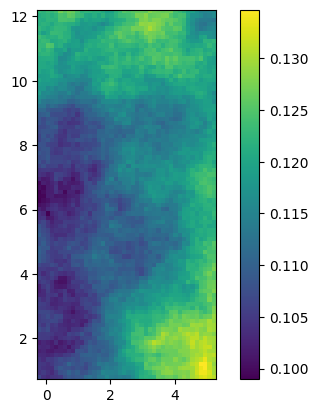

In [4]:
realisation = prior(skey())

plt.imshow(
    realisation.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar()

In [5]:
@jax.jit
def log_likelihood_gaussian(data, data_obs, data_std):
    normalised_residual = (data_obs - data) / data_std
    log_likelihood = -0.5 * jnp.sum(normalised_residual**2)
    return jnp.sum(log_likelihood)


chain = ExtendedMetropolisChain(
    beta=1.0,
    proposal_dist=proposal_dist,
    forward_model=forward_model,
    log_likelihood_fn=log_likelihood_gaussian,
)

In [6]:
N_chains = 3
betas = initialize_betas(n_chains=3)
N_steps = 250

chain_spec = make_pytree_spec(
    chain,
    {
        "beta": 0,
        "proposal_dist.step_size": 0,
        "*": None,
    },
)
@eqx.filter_vmap(in_axes=(0,), out_axes=chain_spec)
def setup_chains(betas):
    return ExtendedMetropolisChain(
        beta=betas,
        proposal_dist=proposal_dist,
        forward_model=forward_model,
        log_likelihood_fn=log_likelihood_gaussian,
    )

@eqx.filter_vmap(in_axes=(0, chain_spec, None))
def get_iteration_state(key, chains, obs):
    return chains.get_iteration_state(
        prior(key), obs
    )

chains = setup_chains(betas)
iter_state_current = get_iteration_state(skey(n=N_chains), chains, obs)

iter_state_current


IterationState(state=f32[3,42,86], log_likelihood=f32[3])

In [7]:
chains

ExtendedMetropolisChain(
  beta=f32[3],
  proposal_dist=ProposalDistribution(
    dist=MultivariateNormalCholesky(
      mean=weak_f32[1], shape=(42, 86), L=f32[3612,3612]
    ),
    step_size=weak_f32[3],
    mean=weak_f32[1]
  ),
  forward_model=<PjitFunction>,
  log_likelihood_fn=<PjitFunction of <function log_likelihood_gaussian at 0x74540ebceae0>>
)

In [8]:
# Tune
N_steps_tune = 500
tune_interval = 100
keep_interval = 10

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(chain_spec, 0, 0), out_axes=(chain_spec, 0, 0))
def get_tuner(chains, key, iter_state):
    return chains.tune(
        n_steps_tune=N_steps_tune,
        tune_interval=tune_interval,
        key=key,
        iter_state=iter_state,
        observations=obs,
        progress=True,
    )

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(None, 0, chain_spec, 0, None))
def step_n_chains(N_steps, key, chains, iter_state, keep_interval):
    return chains.step_n(
        N_steps,
        key=key,
        iter_state=iter_state,
        observations=obs,
        progress=PROGRESS,
        keep_interval=keep_interval,
    )

# Chains

In [9]:
tuned_chains, tuned_iter_state, tune_history = get_tuner(chains, skey(n=N_chains), iter_state_current)
# err, tuned_chains, tuned_iter_state, tune_history) = get_tuner(chains, skey(n=N_chains), iter_state_current)
# err.throw()

Tuning:   0%|          | 0/500 [00:00<?, ?it/s]

In [10]:

n_steps_iter_state, n_steps_history = step_n_chains(
    N_steps, skey(N_chains), tuned_chains, iter_state_current, keep_interval
)


Sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [11]:
n_steps_history

(Array([[ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
         140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
        [ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
         140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
        [ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
         140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250]],      dtype=int32),
 IterationState(state=f32[3,25,42,86], log_likelihood=f32[3,25]),
 Array([[ 7,  5,  3,  6,  6,  2,  5,  5,  7,  5,  5,  3,  7,  6,  4,  3,
          1,  1,  5,  2,  3,  2,  2,  4,  1],
        [ 5,  6,  6,  4,  4,  5,  3,  6,  7,  4,  2,  3,  7,  6,  4,  2,
          1,  3,  1,  5,  4,  2,  2,  2,  2],
        [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
         10, 10, 10, 10, 10, 10, 10, 10, 10]], dtype=int32),
 Array([[ True,  True, False,  True,  True, False, False, False, False,
         False,  True, False,  True, F

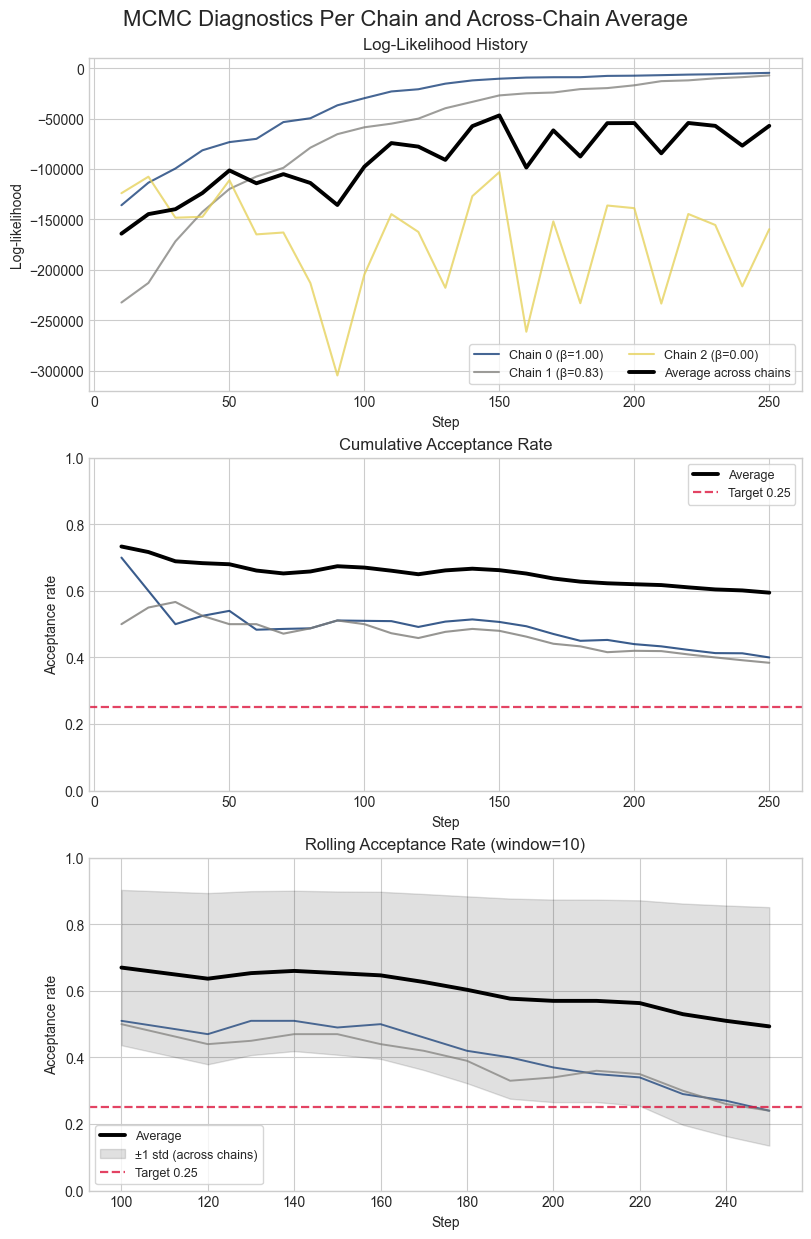

In [12]:
# ------------------------------------------------------------
# Uses output from:
# n_steps_iter_state, n_steps_history = step_n_chains(...)
# ------------------------------------------------------------
history_iterations, history_states, history_n_accepted, history_iter_accepted = n_steps_history

# Extract arrays
logL = np.asarray(history_states.log_likelihood).astype(float)
n_acc = np.asarray(history_n_accepted).astype(float)   # accepted count in each kept block
iter_acc = np.asarray(history_iter_accepted).astype(float)  # last proposal accepted (0/1)
betas = np.asarray(tuned_chains.beta, dtype=float)

# Normalize orientation to (n_chains, n_saved)
n_chains = int(betas.shape[0])

def to_chain_time(arr, name):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape={arr.shape}")
    if arr.shape[0] == n_chains:
        return arr
    if arr.shape[1] == n_chains:
        return arr.T
    raise ValueError(f"Could not infer chain axis for {name}. shape={arr.shape}, n_chains={n_chains}")

logL = to_chain_time(logL, "logL")
n_acc = to_chain_time(n_acc, "history_n_accepted")
iter_acc = to_chain_time(iter_acc, "history_iter_accepted")

n_saved = logL.shape[1]
if n_acc.shape[1] != n_saved or iter_acc.shape[1] != n_saved:
    raise ValueError(
        f"History length mismatch: logL={logL.shape}, n_acc={n_acc.shape}, iter_acc={iter_acc.shape}"
    )

# Build x-axis from history_iterations robustly
iters_raw = np.asarray(history_iterations)
if iters_raw.ndim == 1:
    steps = iters_raw.astype(int)
elif iters_raw.ndim == 2:
    if iters_raw.shape == (n_chains, n_saved):
        steps = np.asarray(iters_raw[0], dtype=int)
    elif iters_raw.shape == (n_saved, n_chains):
        steps = np.asarray(iters_raw[:, 0], dtype=int)
    else:
        raise ValueError(f"Unexpected history_iterations shape={iters_raw.shape}")
else:
    raise ValueError(f"history_iterations must be 1D or 2D, got shape={iters_raw.shape}")

if steps.shape[0] != n_saved:
    raise ValueError(f"steps length mismatch: len(steps)={len(steps)}, n_saved={n_saved}")

# Attempts per kept point (usually keep_interval)
block_sizes = np.diff(np.concatenate(([0], steps))).astype(float)
if np.any(block_sizes <= 0):
    raise ValueError(f"Non-increasing history_iterations found: {steps}")

# Per-kept-block acceptance rate (proposal-level)
accept = n_acc / block_sizes[None, :]

# Metrics
# IMPORTANT: cumulative_rate must stay per-chain (2D), not collapsed over chains
cumulative_accepts = np.cumsum(n_acc, axis=1)
cumulative_attempts = np.cumsum(np.broadcast_to(block_sizes, (n_chains, n_saved)), axis=1)
cumulative_rate = cumulative_accepts / cumulative_attempts

window = min(75, max(10, n_saved // 20))
window = min(window, n_saved)
window = max(window, 1)

kernel = np.ones(window, dtype=float)
rolling_num = np.array([np.convolve(n_acc[i], kernel, mode="valid") for i in range(n_chains)])
rolling_den = np.convolve(block_sizes, kernel, mode="valid")
rolling_rate = rolling_num / rolling_den[None, :]
rolling_steps = steps[window - 1 :]

# Averages across chains
avg_logL = np.mean(logL, axis=0)
avg_cum_rate = np.mean(cumulative_rate, axis=0)
avg_rolling = np.mean(rolling_rate, axis=0)
std_rolling = np.std(rolling_rate, axis=0)

# Style
plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.cm.cividis(np.linspace(0.1, 0.9, n_chains))

fig, axes = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

# Log-likelihood history
ax = axes[0]
for i in range(n_chains):
    ax.plot(
        steps, logL[i], color=colors[i], lw=1.5, alpha=0.75,
        label=f"Chain {i} (β={betas[i]:.2f})"
    )
ax.plot(steps, avg_logL, color="black", lw=2.8, label="Average across chains")
ax.set_title("Log-Likelihood History")
ax.set_xlabel("Step")
ax.set_ylabel("Log-likelihood")
ax.legend(frameon=True, fontsize=9, ncol=2)

# Cumulative acceptance rate
ax = axes[1]
for i in range(n_chains):
    ax.plot(steps, cumulative_rate[i], color=colors[i], lw=1.5, alpha=0.8)
ax.plot(steps, avg_cum_rate, color="black", lw=2.8, label="Average")
ax.axhline(0.25, color="crimson", ls="--", lw=1.6, alpha=0.8, label="Target 0.25")
ax.set_title("Cumulative Acceptance Rate")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=9)

# Rolling acceptance rate
ax = axes[2]
for i in range(n_chains):
    ax.plot(rolling_steps, rolling_rate[i], color=colors[i], lw=1.4, alpha=0.7)
ax.plot(rolling_steps, avg_rolling, color="black", lw=2.8, label="Average")
ax.fill_between(
    rolling_steps,
    np.clip(avg_rolling - std_rolling, 0, 1),
    np.clip(avg_rolling + std_rolling, 0, 1),
    color="black",
    alpha=0.12,
    label="±1 std (across chains)"
)
ax.axhline(0.25, color="crimson", ls="--", lw=1.6, alpha=0.8, label="Target 0.25")
ax.set_title(f"Rolling Acceptance Rate (window={window})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=9)

fig.suptitle("MCMC Diagnostics Per Chain and Across-Chain Average", fontsize=16, y=1.02)
plt.show()

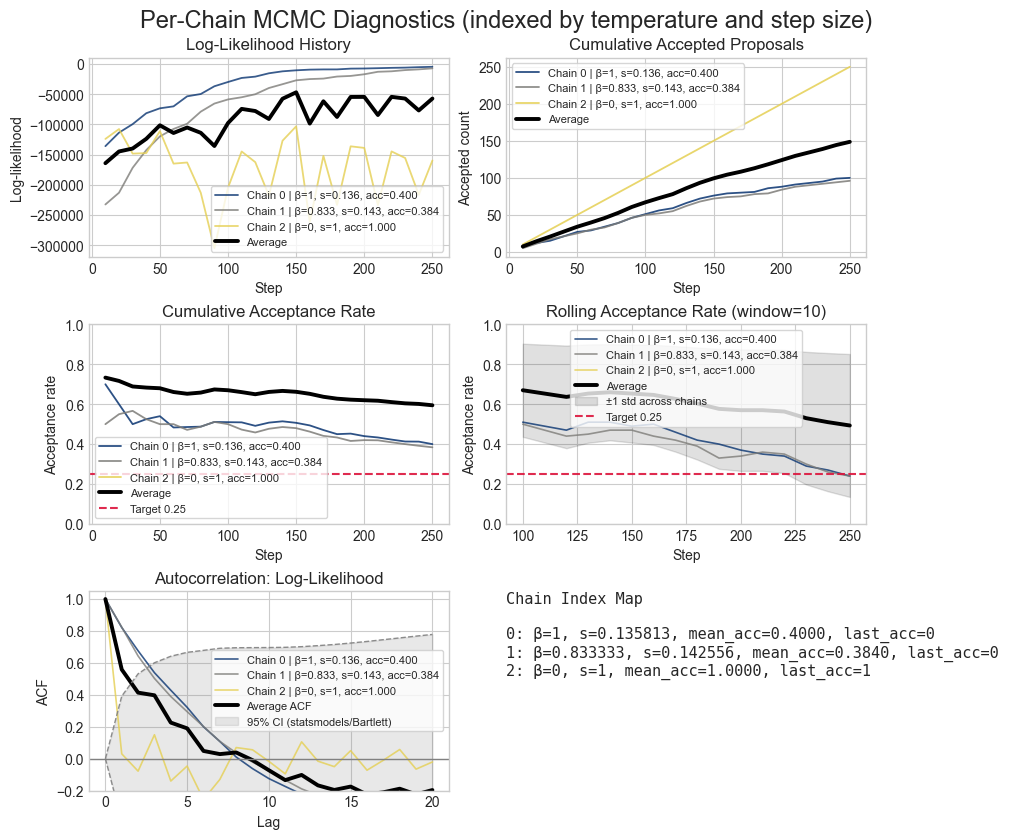

In [13]:
# ------------------------------------------------------------------
# Input expected from:
# n_steps_iter_state, n_steps_history = step_n_chains(...)
# ------------------------------------------------------------------
history_iterations, history_states, history_n_accepted, history_iter_accepted = n_steps_history

logL = np.asarray(history_states.log_likelihood).astype(float)
n_acc = np.asarray(history_n_accepted).astype(float)          # accepted proposals per kept block
iter_acc = np.asarray(history_iter_accepted).astype(float)    # last proposal accepted in block (0/1)

betas = np.asarray(tuned_chains.beta, dtype=float)
step_sizes = np.asarray(tuned_chains.proposal_dist.step_size, dtype=float)

n_chains = int(betas.shape[0])

if step_sizes.ndim == 0:
    step_sizes = np.full(n_chains, float(step_sizes))


def to_chain_time(arr, name):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape={arr.shape}")
    if arr.shape[0] == n_chains:
        return arr
    if arr.shape[1] == n_chains:
        return arr.T
    raise ValueError(f"Could not infer chain axis for {name}. shape={arr.shape}, n_chains={n_chains}")


logL = to_chain_time(logL, "logL")
n_acc = to_chain_time(n_acc, "history_n_accepted")
iter_acc = to_chain_time(iter_acc, "history_iter_accepted")

n_saved = logL.shape[1]
if n_acc.shape[1] != n_saved or iter_acc.shape[1] != n_saved:
    raise ValueError(
        f"History length mismatch: logL={logL.shape}, n_acc={n_acc.shape}, iter_acc={iter_acc.shape}"
    )

# Build x-axis from stored kept-iteration indices
iters_raw = np.asarray(history_iterations)
if iters_raw.ndim == 1:
    steps = iters_raw.astype(int)
elif iters_raw.ndim == 2:
    if iters_raw.shape == (n_chains, n_saved):
        steps = np.asarray(iters_raw[0], dtype=int)
    elif iters_raw.shape == (n_saved, n_chains):
        steps = np.asarray(iters_raw[:, 0], dtype=int)
    else:
        raise ValueError(f"Unexpected history_iterations shape={iters_raw.shape}")
else:
    raise ValueError(f"history_iterations must be 1D or 2D, got shape={iters_raw.shape}")

if steps.shape[0] != n_saved:
    raise ValueError(f"steps length mismatch: len(steps)={len(steps)}, n_saved={n_saved}")

# Attempts per kept block (typically keep_interval)
block_sizes = np.diff(np.concatenate(([0], steps))).astype(float)
if np.any(block_sizes <= 0):
    raise ValueError(f"Non-increasing history_iterations found: {steps}")

# Proposal-level acceptance rate per kept block
accept_rate = n_acc / block_sizes[None, :]

# Acceptance metrics
cumulative_accepts = np.cumsum(n_acc, axis=1)
cumulative_attempts = np.cumsum(np.broadcast_to(block_sizes, (n_chains, n_saved)), axis=1)
cumulative_rate = cumulative_accepts / cumulative_attempts

window = min(75, max(10, n_saved // 20))
window = min(window, n_saved)
window = max(window, 1)

kernel = np.ones(window, dtype=float)
rolling_num = np.array([np.convolve(n_acc[i], kernel, mode="valid") for i in range(n_chains)])
rolling_den = np.convolve(block_sizes, kernel, mode="valid")
rolling_rate = rolling_num / rolling_den[None, :]
rolling_steps = steps[window - 1 :]

# Cross-chain summaries
avg_logL = np.mean(logL, axis=0)
avg_cum_accepts = np.mean(cumulative_accepts, axis=0)
avg_cum_rate = np.mean(cumulative_rate, axis=0)
avg_rolling = np.mean(rolling_rate, axis=0)
std_rolling = np.std(rolling_rate, axis=0)

# ACF only for log-likelihood
if n_saved < 2:
    raise ValueError("Need at least 2 saved points to compute ACF.")
alpha = 0.05
max_lag = min(250, max(20, n_saved // 4), n_saved - 1)
lags = np.arange(max_lag + 1)

acf_logL = []
ci0_logL = []  # zero-centered CI
for i in range(n_chains):
    a, ci = acf(logL[i], nlags=max_lag, fft=True, alpha=alpha, bartlett_confint=True)
    acf_logL.append(a)
    ci0_logL.append(ci - a[:, None])

acf_logL = np.asarray(acf_logL)
ci0_logL = np.asarray(ci0_logL)

avg_acf_logL = acf_logL.mean(axis=0)
avg_low_logL = ci0_logL[:, :, 0].mean(axis=0)
avg_high_logL = ci0_logL[:, :, 1].mean(axis=0)

# Labels per chain
mean_block_rate = accept_rate.mean(axis=1)
chain_labels = [
    f"Chain {i} | β={betas[i]:.3g}, s={step_sizes[i]:.3g}, acc={mean_block_rate[i]:.3f}"
    for i in range(n_chains)
]

# Plot styling
plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.cm.cividis(np.linspace(0.1, 0.9, n_chains))

fig, axes = plt.subplots(3, 2, figsize=(10, 8), constrained_layout=True)

# 1) Log-likelihood traces
ax = axes[0, 0]
for i in range(n_chains):
    ax.plot(steps, logL[i], color=colors[i], lw=1.3, alpha=0.8, label=chain_labels[i])
ax.plot(steps, avg_logL, color="black", lw=2.8, label="Average")
ax.set_title("Log-Likelihood History")
ax.set_xlabel("Step")
ax.set_ylabel("Log-likelihood")
ax.legend(frameon=True, fontsize=8, ncol=1)

# 2) Cumulative accepts
ax = axes[0, 1]
for i in range(n_chains):
    ax.plot(steps, cumulative_accepts[i], color=colors[i], lw=1.3, alpha=0.85, label=chain_labels[i])
ax.plot(steps, avg_cum_accepts, color="black", lw=2.8, label="Average")
ax.set_title("Cumulative Accepted Proposals")
ax.set_xlabel("Step")
ax.set_ylabel("Accepted count")
ax.legend(frameon=True, fontsize=8, ncol=1)

# 3) Cumulative acceptance rate
ax = axes[1, 0]
for i in range(n_chains):
    ax.plot(steps, cumulative_rate[i], color=colors[i], lw=1.3, alpha=0.85, label=chain_labels[i])
ax.plot(steps, avg_cum_rate, color="black", lw=2.8, label="Average")
ax.axhline(0.25, color="crimson", ls="--", lw=1.5, alpha=0.9, label="Target 0.25")
ax.set_title("Cumulative Acceptance Rate")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=8, ncol=1)

# 4) Rolling acceptance rate
ax = axes[1, 1]
for i in range(n_chains):
    ax.plot(rolling_steps, rolling_rate[i], color=colors[i], lw=1.2, alpha=0.8, label=chain_labels[i])
ax.plot(rolling_steps, avg_rolling, color="black", lw=2.8, label="Average")
ax.fill_between(
    rolling_steps,
    np.clip(avg_rolling - std_rolling, 0, 1),
    np.clip(avg_rolling + std_rolling, 0, 1),
    color="black",
    alpha=0.12,
    label="±1 std across chains",
)
ax.axhline(0.25, color="crimson", ls="--", lw=1.5, alpha=0.9, label="Target 0.25")
ax.set_title(f"Rolling Acceptance Rate (window={window})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=8, ncol=1)

# 5) ACF of log-likelihood with statsmodels bounds
ax = axes[2, 0]
for i in range(n_chains):
    ax.plot(lags, acf_logL[i], color=colors[i], lw=1.2, alpha=0.8, label=chain_labels[i])
ax.plot(lags, avg_acf_logL, color="black", lw=2.8, label="Average ACF")
ax.fill_between(
    lags, avg_low_logL, avg_high_logL,
    color="gray", alpha=0.18,
    label=f"{int((1-alpha)*100)}% CI (statsmodels/Bartlett)",
)
ax.plot(lags, avg_high_logL, color="gray", ls="--", lw=1.0, alpha=0.9)
ax.plot(lags, avg_low_logL, color="gray", ls="--", lw=1.0, alpha=0.9)
ax.axhline(0.0, color="gray", lw=1.0)
ax.set_title("Autocorrelation: Log-Likelihood")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_ylim(-0.2, 1.05)
ax.legend(frameon=True, fontsize=8, ncol=1)

# 6) Legend/info panel
ax = axes[2, 1]
ax.axis("off")
info_lines = [
    f"{i}: β={betas[i]:.6g}, s={step_sizes[i]:.6g}, mean_acc={mean_block_rate[i]:.4f}, last_acc={iter_acc[i, -1]:.0f}"
    for i in range(n_chains)
]
ax.text(
    0.0, 1.0,
    "Chain Index Map\n\n" + "\n".join(info_lines),
    va="top", ha="left", fontsize=11, family="monospace"
)

fig.suptitle("Per-Chain MCMC Diagnostics (indexed by temperature and step size)", fontsize=17, y=1.03)
plt.show()

# PT

In [ ]:
# Single-cell PT setup + tune + production run (no extra burn-in)
# ----------------------------
# Configuration
# ----------------------------
N_chains = 32

N_steps_pre_burn_in = 1000
N_steps_tune = 1200
N_steps = 1200

tune_interval = 150
keep_interval = 10
window = 75

temp_min = 1.0
temp_max = 1000

step_size_min = 0.03
step_size_max = 0.3

target_chain_acceptance = 0.25
target_swap_acceptance = 0.25

learning_rate_step_size=0.2
learning_rate_step_size_decay=0.8
learning_rate_beta=0.05
learning_rate_beta_decay=0.9

betas = initialize_betas(n_chains=N_chains)
step_sizes = jnp.linspace(step_size_min, step_size_max, N_chains)

# ----------------------------
# Build vectorized chains
# ----------------------------
chain_template = ExtendedMetropolisChain(
    beta=1.0,
    proposal_dist=proposal_dist,          # from notebook setup
    forward_model=forward_model,          # from notebook setup
    log_likelihood_fn=log_likelihood_gaussian,
)

chain_spec = make_pytree_spec(
    chain_template,
    {
        "beta": 0,
        "proposal_dist.step_size": 0,
        "*": None,
    },
)

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(0, 0), out_axes=chain_spec)
def make_chain(beta, step):
    return ExtendedMetropolisChain(
        beta=beta,
        proposal_dist=ProposalDistribution(dist=prior, step_size=step),
        forward_model=forward_model,
        log_likelihood_fn=log_likelihood_gaussian,
    )

chains = make_chain(betas, step_sizes)

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(0, chain_spec, None))
def init_state(k, c, obs_):
    return c.get_iteration_state(prior(k), obs_)

iter_states0 = init_state(skey(n=N_chains), chains, obs)

pt = ParallelTemperingSampler(chains=chains, chain_axes_spec=chain_spec)

# Pre-burn-in PT
iter_states_burnt_in, pre_burn_in_history = pt.step_n(
    N_steps_pre_burn_in,
    key=skey(),
    iter_states=iter_states0,
    observations=obs,
    progress=PROGRESS,
    keep_interval=keep_interval,
)

PT Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

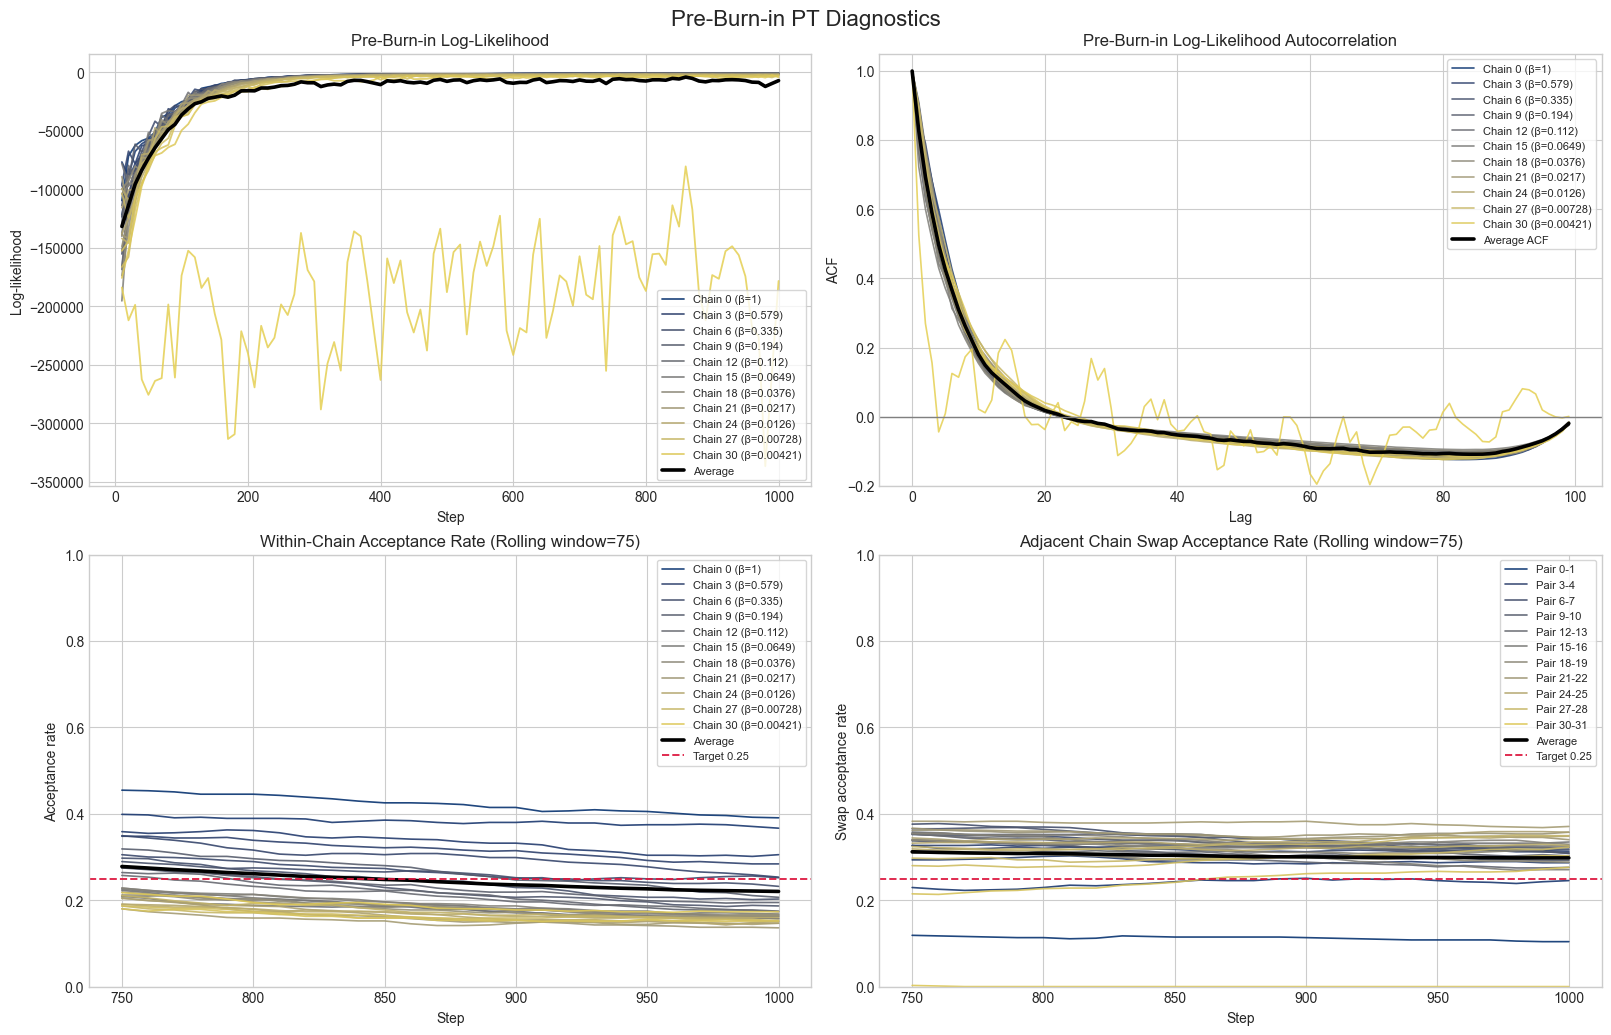

In [19]:
# Exact unpack based on the step_n return signature
(
    history_iterations_pre,
    history_states_pre,
    total_sw_acc_pre,
    total_loc_acc_pre,
    sw_last_pre,
    loc_last_pre,
) = pre_burn_in_history

# Transpose arrays so time is the last axis: (n_chains/n_pairs, n_saved)
logL = np.asarray(history_states_pre.log_likelihood).T
chain_n_acc = np.asarray(total_loc_acc_pre).T
swap_n_acc = np.asarray(total_sw_acc_pre).T
betas = np.asarray(chains.beta)

n_chains, n_saved = logL.shape
n_pairs = n_chains - 1
steps = np.asarray(history_iterations_pre)

# Attempts in each kept block
block_sizes = np.diff(np.concatenate(([0], steps)))

# Rolling window setup
window_pre = 75
kernel = np.ones(window_pre)
roll_den = np.convolve(block_sizes, kernel, mode="valid")
roll_steps = steps[window_pre - 1:]

# Chain rolling acceptance
chain_roll_num = np.array([np.convolve(chain_n_acc[i], kernel, mode="valid") for i in range(n_chains)])
chain_roll_rate = chain_roll_num / roll_den[None, :]

# Swap rolling acceptance
swap_roll_num = np.array([np.convolve(swap_n_acc[i], kernel, mode="valid") for i in range(n_pairs)])
swap_roll_rate = swap_roll_num / roll_den[None, :]

# ACF diagnostics (log-likelihood)
max_lag = min(250, n_saved - 1)
lags = np.arange(max_lag + 1)
# Removed the [0] here!
acf_logL = np.asarray([acf(logL[i], nlags=max_lag, fft=True) for i in range(n_chains)])
avg_acf = acf_logL.mean(axis=0)

# Aesthetics and Labels
plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.cm.cividis(np.linspace(0.1, 0.9, n_chains))
legend_stride = max(1, n_chains // 10)

def chain_label(i):
    return f"Chain {i} (β={betas[i]:.3g})" if (i % legend_stride == 0) else "_nolegend_"

def swap_label(i):
    return f"Pair {i}-{i+1}" if (i % legend_stride == 0) else "_nolegend_"

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# 1) Log-likelihood Trace
ax = axes[0, 0]
for i in range(n_chains):
    ax.plot(steps, logL[i], color=colors[i], lw=1.3, alpha=0.85, label=chain_label(i))
ax.plot(steps, logL.mean(axis=0), color="black", lw=2.6, label="Average")
ax.set_title("Pre-Burn-in Log-Likelihood")
ax.set_xlabel("Step")
ax.set_ylabel("Log-likelihood")
ax.legend(fontsize=8, frameon=True)

# 2) Autocorrelation
ax = axes[0, 1]
for i in range(n_chains):
    ax.plot(lags, acf_logL[i], color=colors[i], lw=1.2, alpha=0.85, label=chain_label(i))
ax.plot(lags, avg_acf, color="black", lw=2.6, label="Average ACF")
ax.axhline(0.0, color="gray", lw=1.0)
ax.set_title("Pre-Burn-in Log-Likelihood Autocorrelation")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_ylim(-0.2, 1.05)
ax.legend(fontsize=8, frameon=True)

# 3) Rolling Within-Chain Acceptance Rate
ax = axes[1, 0]
for i in range(n_chains):
    ax.plot(roll_steps, chain_roll_rate[i], color=colors[i], lw=1.2, alpha=0.9, label=chain_label(i))
ax.plot(roll_steps, chain_roll_rate.mean(axis=0), color="black", lw=2.6, label="Average")
ax.axhline(target_chain_acceptance, color="crimson", ls="--", lw=1.4, alpha=0.9, label=f"Target {target_chain_acceptance:.2f}")
ax.set_title(f"Within-Chain Acceptance Rate (Rolling window={window_pre})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=8, frameon=True)

# 4) Rolling Swap Acceptance Rate
ax = axes[1, 1]
for i in range(n_pairs):
    ax.plot(roll_steps, swap_roll_rate[i], color=colors[i], lw=1.2, alpha=0.9, label=swap_label(i))
ax.plot(roll_steps, swap_roll_rate.mean(axis=0), color="black", lw=2.6, label="Average")
ax.axhline(target_swap_acceptance, color="crimson", ls="--", lw=1.4, alpha=0.9, label=f"Target {target_swap_acceptance:.2f}")
ax.set_title(f"Adjacent Chain Swap Acceptance Rate (Rolling window={window_pre})")
ax.set_xlabel("Step")
ax.set_ylabel("Swap acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=8, frameon=True)

fig.suptitle("Pre-Burn-in PT Diagnostics", fontsize=16, y=1.02)
plt.show()


In [ ]:
# ----------------------------
# Tune PT first
# ----------------------------
pt_tuned, iter_states_tuned, tune_history = pt.tune(
    n_steps_tune=N_steps_tune,
    tune_interval=tune_interval,
    key=skey(),
    iter_states=iter_states_burnt_in,
    observations=obs,
    initial_step_size=step_sizes,
    initial_betas=betas,
    target_chain_acceptance_rate=target_chain_acceptance,
    target_swap_acceptance_rate=target_swap_acceptance,
    learning_rate_step_size=learning_rate_step_size,
    learning_rate_step_size_decay=learning_rate_step_size_decay,
    learning_rate_beta=learning_rate_beta,
    learning_rate_beta_decay=learning_rate_beta_decay,
    keep_interval=keep_interval,
    progress=PROGRESS,
)



PT Tuning:   0%|          | 0/1200 [00:00<?, ?it/s]

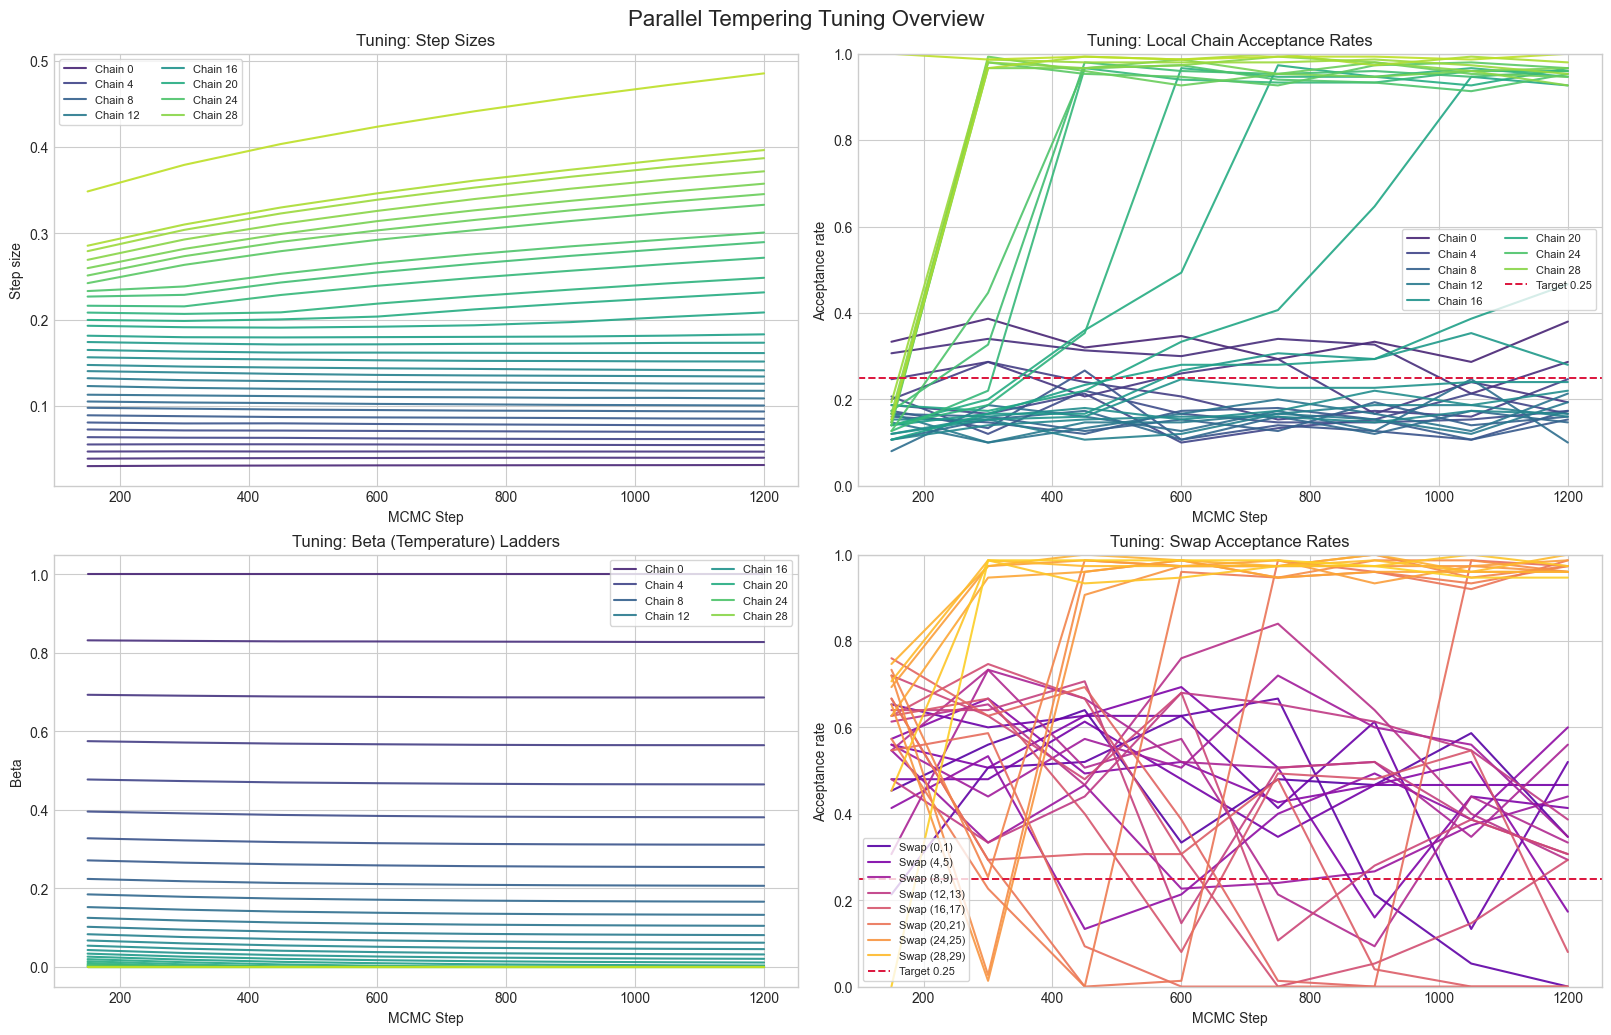

Tuning outcome:
  Initial step sizes: [0.03       0.03870968 0.04741935 0.05612903 0.06483871 0.07354838
 0.08225806 0.09096774 0.09967742 0.1083871  0.11709677 0.12580645
 0.13451613 0.1432258  0.15193549 0.16064516 0.16935484 0.17806453
 0.1867742  0.19548388 0.20419355 0.21290323 0.22161292 0.23032257
 0.23903225 0.24774194 0.2564516  0.26516128 0.27387097 0.28258064
 0.2912903  0.3       ]
  Final step sizes:   [0.03177223 0.04023701 0.04725151 0.05488624 0.06161892 0.07001723
 0.07764536 0.08533631 0.09376163 0.10066505 0.1088723  0.11772324
 0.1259077  0.13426341 0.14144367 0.15159298 0.16141787 0.17337216
 0.18308526 0.20842804 0.23167904 0.24856944 0.27178428 0.28985593
 0.3009845  0.33308586 0.34548843 0.35754293 0.37185654 0.3870741
 0.3964477  0.48526716]
  Initial betas: [1.         0.83333331 0.69444442 0.57870364 0.48225302 0.40187749
 0.33489791 0.27908158 0.23256797 0.19380663 0.16150552 0.13458793
 0.1121566  0.09346383 0.07788652 0.06490543 0.05408786 0.04507321
 0.03

In [ ]:
beta_iterations, _, step_size_hist, local_acc_hist, betas_hist, swap_acc_hist = tune_history

step_size_hist = np.asarray(step_size_hist, dtype=float)
local_acc_hist = np.asarray(local_acc_hist, dtype=float)
betas_hist = np.asarray(betas_hist, dtype=float)
swap_acc_hist = np.asarray(swap_acc_hist, dtype=float)

n_chains = int(np.asarray(pt_tuned.chains.beta).shape[0])
n_pairs = max(0, n_chains - 1)

def to_saved_chain(arr, name, n_cols_expected):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape={arr.shape}")
    if arr.shape[1] == n_cols_expected:
        return arr
    if arr.shape[0] == n_cols_expected:
        return arr.T
    raise ValueError(
        f"Could not infer orientation for {name}: shape={arr.shape}, expected columns={n_cols_expected}"
    )

step_size_hist = to_saved_chain(step_size_hist, "step_size_hist", n_chains)
local_acc_hist = to_saved_chain(local_acc_hist, "local_acc_hist", n_chains)
betas_hist = to_saved_chain(betas_hist, "betas_hist", n_chains)

# Handle swap array shape edge cases
if n_pairs == 0:
    swap_acc_hist = np.zeros((step_size_hist.shape[0], 0), dtype=float)
else:
    if swap_acc_hist.ndim == 1:
        swap_acc_hist = swap_acc_hist[:, None]
    swap_acc_hist = to_saved_chain(swap_acc_hist, "swap_acc_hist", n_pairs)

n_saved = step_size_hist.shape[0]
ti = np.asarray(tune_iterations)
if ti.ndim == 1:
    tune_steps = ti.astype(int)
elif ti.ndim == 2:
    if ti.shape[0] == n_saved:
        tune_steps = ti[:, 0].astype(int)
    elif ti.shape[1] == n_saved:
        tune_steps = ti[0].astype(int)
    else:
        raise ValueError(f"Unexpected tune_iterations shape: {ti.shape}")
else:
    raise ValueError(f"Unexpected tune_iterations ndim: {ti.ndim}")
x_label = "MCMC Step"

chain_labels = [f"Chain {i}" for i in range(n_chains)]
pair_labels = [f"Swap ({j},{j+1})" for j in range(n_pairs)]

c_chains = plt.cm.viridis(np.linspace(0.1, 0.9, max(n_chains, 2)))[:n_chains]
c_pairs = plt.cm.plasma(np.linspace(0.15, 0.9, max(n_pairs, 2)))[:n_pairs]

# Legend striding for readability
chain_legend_stride = 1 if n_chains <= 10 else int(np.ceil(n_chains / 10))
pair_legend_stride = 1 if n_pairs <= 10 else int(np.ceil(n_pairs / 10))

def stride_label(labels, i, stride):
    return labels[i] if (i % stride == 0) else "_nolegend_"

# Tuning overview plots
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# 1) Step-size trajectories
ax = axes[0, 0]
for i in range(n_chains):
    ax.plot(
        tune_steps,
        step_size_hist[:, i],
        color=c_chains[i],
        lw=1.5,
        alpha=0.9,
        label=stride_label(chain_labels, i, chain_legend_stride),
    )
ax.set_title("Tuning: Step Sizes")
ax.set_xlabel(x_label)
ax.set_ylabel("Step size")
ax.legend(fontsize=8, ncol=2, frameon=True)

# 2) Local within-chain acceptance rates
ax = axes[0, 1]
for i in range(n_chains):
    ax.plot(
        tune_steps,
        local_acc_hist[:, i],
        color=c_chains[i],
        lw=1.5,
        alpha=0.9,
        label=stride_label(chain_labels, i, chain_legend_stride),
    )
ax.axhline(
    target_chain_acceptance,
    color="crimson",
    ls="--",
    lw=1.4,
    label=f"Target {target_chain_acceptance:.2f}",
)
ax.set_ylim(0.0, 1.0)
ax.set_title("Tuning: Local Chain Acceptance Rates")
ax.set_xlabel(x_label)
ax.set_ylabel("Acceptance rate")
ax.legend(fontsize=8, ncol=2, frameon=True)

# 3) Beta (Temperature) ladder trajectories
ax = axes[1, 0]
for i in range(n_chains):
    ax.plot(
        tune_steps,
        betas_hist[:, i],
        color=c_chains[i],
        lw=1.5,
        alpha=0.9,
        label=stride_label(chain_labels, i, chain_legend_stride),
    )
ax.set_title("Tuning: Beta (Temperature) Ladders")
ax.set_xlabel(x_label)
ax.set_ylabel("Beta")
ax.legend(fontsize=8, ncol=2, frameon=True)

# 4) Swap acceptance rates per adjacent pair
ax = axes[1, 1]
if n_pairs > 0:
    for j in range(n_pairs):
        ax.plot(
            tune_steps,
            swap_acc_hist[:, j],
            color=c_pairs[j],
            lw=1.5,
            alpha=0.9,
            label=stride_label(pair_labels, j, pair_legend_stride),
        )
    ax.axhline(
        target_swap_acceptance,
        color="crimson",
        ls="--",
        lw=1.4,
        label=f"Target {target_swap_acceptance:.2f}",
    )
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8, ncol=1, frameon=True)
else:
    ax.text(0.5, 0.5, "No swap pairs (n_chains < 2)", ha="center", va="center", fontsize=11)
ax.set_title("Tuning: Swap Acceptance Rates")
ax.set_xlabel(x_label)
ax.set_ylabel("Acceptance rate")

fig.suptitle("Parallel Tempering Tuning Overview", fontsize=16, y=1.02)
plt.show()

# Tuning outcome summary
print("Tuning outcome:")
print("  Initial step sizes:", np.asarray(step_sizes))
print("  Final step sizes:  ", np.asarray(pt_tuned.chains.proposal_dist.step_size))
print("  Initial betas:", np.asarray(betas))
print("  Final betas:  ", np.asarray(pt_tuned.chains.beta))
print("  Final local acceptance (per chain):", local_acc_hist[-1])
if n_pairs > 0:
    print("  Final swap acceptance (per pair):  ", swap_acc_hist[-1])
else:
    print("  Final swap acceptance (per pair):   []")

In [ ]:

# ----------------------------
# Production run (start from tuned state; no extra burn-in)
# ----------------------------
(final_iter_states,), history = pt_tuned.step_n(
    n=N_steps,
    key=skey(),
    iter_states=iter_states_tuned,
    observations=obs,
    progress=True,
)

# history now includes local acceptances too
hist_states, swap_accept_hist, local_accept_hist = history

PT Sampling:   0%|          | 0.00/1.20k [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 3, got 6)

In [ ]:
# ----------------------------
# Convert outputs
# ----------------------------
states_hist = np.asarray(hist_states.state)                  # expected: (steps, chains, nx, ny)
logL_hist = np.asarray(hist_states.log_likelihood)           # expected: (steps, chains)
swap_hist = np.asarray(swap_accept_hist).astype(float)       # expected: (steps, chains-1)
local_hist = np.asarray(local_accept_hist).astype(float)     # expected: (steps, chains)

# ----------------------------
# Normalize orientations
# ----------------------------
if logL_hist.ndim != 2:
    raise ValueError(f"logL_hist must be 2D, got shape={logL_hist.shape}")

# Put chain axis in dim=1 => (steps, chains)
if logL_hist.shape[1] == N_chains:
    pass
elif logL_hist.shape[0] == N_chains:
    logL_hist = logL_hist.T
else:
    raise ValueError(
        f"Could not infer chain axis from logL_hist.shape={logL_hist.shape}, N_chains={N_chains}"
    )

n_steps = logL_hist.shape[0]
n_chains_hist = logL_hist.shape[1]

# states: ensure (steps, chains, nx, ny)
if states_hist.shape[0] != n_steps and states_hist.shape[1] == n_steps:
    states_hist = np.swapaxes(states_hist, 0, 1)
if states_hist.shape[1] != n_chains_hist:
    raise ValueError(
        f"states_hist chain axis mismatch: states_hist.shape={states_hist.shape}, expected chains={n_chains_hist}"
    )

# swap: ensure (steps, chains-1)
if swap_hist.ndim != 2:
    raise ValueError(f"swap_hist must be 2D, got shape={swap_hist.shape}")
if swap_hist.shape[0] != n_steps and swap_hist.shape[1] == n_steps:
    swap_hist = swap_hist.T

# local accepts: ensure (steps, chains)
if local_hist.ndim != 2:
    raise ValueError(f"local_hist must be 2D, got shape={local_hist.shape}")
if local_hist.shape[0] != n_steps and local_hist.shape[1] == n_steps:
    local_hist = local_hist.T
if local_hist.shape[1] != n_chains_hist:
    raise ValueError(
        f"local_hist chain axis mismatch: local_hist.shape={local_hist.shape}, expected chains={n_chains_hist}"
    )

steps = np.arange(1, n_steps + 1)

# ----------------------------
# Use tuned ladder/step sizes if available
# ----------------------------
T = np.asarray(pt_tuned.chains.temperature, dtype=float)
S = np.asarray(pt_tuned.chains.proposal_dist.step_size, dtype=float)

if S.ndim == 0:
    S = np.full_like(T, float(S), dtype=float)

# ----------------------------
# Swap acceptance diagnostics (attempt-aware)
# ----------------------------
n_pairs = n_chains_hist - 1

pair_idx = np.arange(n_pairs)[None, :]
step_idx = np.arange(n_steps)[:, None]
attempted = ((pair_idx % 2) == (step_idx % 2)).astype(float)

cum_swap_accept = np.cumsum(swap_hist, axis=0)
cum_attempts = np.cumsum(attempted, axis=0)
cum_swap_rate = np.divide(cum_swap_accept, np.maximum(cum_attempts, 1.0))

window_eff = int(min(window, n_steps))
window_eff = max(window_eff, 2)
kernel = np.ones(window_eff, dtype=float)

roll_acc_num = np.vstack(
    [np.convolve(swap_hist[:, j], kernel, mode="valid") for j in range(n_pairs)]
).T
roll_att_num = np.vstack(
    [np.convolve(attempted[:, j], kernel, mode="valid") for j in range(n_pairs)]
).T
roll_swap_rate = np.divide(roll_acc_num, np.maximum(roll_att_num, 1.0))
roll_steps = np.arange(window_eff, n_steps + 1)

# ----------------------------
# Local acceptance diagnostics (new: from local_accept_hist)
# ----------------------------
cum_local_accept = np.cumsum(local_hist, axis=0)
cum_local_rate = cum_local_accept / steps[:, None]

roll_local_num = np.vstack(
    [np.convolve(local_hist[:, i], kernel, mode="valid") for i in range(n_chains_hist)]
).T
roll_local_rate = roll_local_num / window_eff

# ----------------------------
# Cold-chain posterior summaries
# ----------------------------
# Default to no additional burn-in unless burn_frac is defined in the notebook.
burn_frac_eff = float(globals().get("burn_frac", 0.0))
burn_frac_eff = min(max(burn_frac_eff, 0.0), 0.99)
burn = int(burn_frac_eff * n_steps)

cold_idx = int(np.argmin(T))  # robust even if chain order changes upstream
cold_samples = states_hist[burn:, cold_idx]
cold_mean = cold_samples.mean(axis=0)
cold_var = cold_samples.var(axis=0)

# ----------------------------
# Labels/colors
# ----------------------------
chain_labels = [f"Chain {i}: T={T[i]:.3g}, s={S[i]:.3g}" for i in range(n_chains_hist)]
pair_labels = [f"Swap ({j},{j+1})" for j in range(n_pairs)]

c_chains = plt.cm.viridis(np.linspace(0.1, 0.9, n_chains_hist))
c_pairs = plt.cm.plasma(np.linspace(0.15, 0.9, n_pairs))

target_swap = float(globals().get("target_swap_acceptance", 0.25))
target_local = float(globals().get("target_chain_acceptance", 0.25))

# ----------------------------
# Plot
# ----------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 14), constrained_layout=True)

# 1) Log-likelihood traces (all chains + average)
ax = axes[0, 0]
for i in range(n_chains_hist):
    ax.plot(steps, logL_hist[:, i], color=c_chains[i], lw=1.2, alpha=0.85, label=chain_labels[i])
ax.plot(steps, logL_hist.mean(axis=1), color="black", lw=2.5, label="Average")
ax.set_title("Per-Chain Log-Likelihood")
ax.set_xlabel("Step")
ax.set_ylabel("Log-likelihood")
ax.legend(fontsize=8, frameon=True, ncol=1)

# 2) Cumulative swap acceptance rate (attempt-aware)
ax = axes[0, 1]
for j in range(n_pairs):
    ax.plot(steps, cum_swap_rate[:, j], color=c_pairs[j], lw=1.4, alpha=0.9, label=pair_labels[j])
ax.axhline(target_swap, color="crimson", ls="--", lw=1.4, alpha=0.9, label=f"Target {target_swap:.2f}")
ax.set_ylim(0, 1)
ax.set_title("Cumulative Swap Acceptance Rate")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.legend(fontsize=8, frameon=True, ncol=1)

# 3) Rolling swap acceptance rate (attempt-aware)
ax = axes[1, 0]
for j in range(n_pairs):
    ax.plot(roll_steps, roll_swap_rate[:, j], color=c_pairs[j], lw=1.4, alpha=0.9, label=pair_labels[j])
ax.axhline(target_swap, color="crimson", ls="--", lw=1.4, alpha=0.9, label=f"Target {target_swap:.2f}")
ax.set_ylim(0, 1)
ax.set_title(f"Rolling Swap Acceptance Rate (window={window_eff})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.legend(fontsize=8, frameon=True, ncol=1)

# 4) Rolling local acceptance rate (all chains)
ax = axes[1, 1]
for i in range(n_chains_hist):
    ax.plot(roll_steps, roll_local_rate[:, i], color=c_chains[i], lw=1.2, alpha=0.9, label=chain_labels[i])
ax.plot(roll_steps, roll_local_rate.mean(axis=1), color="black", lw=2.2, label="Average rolling local")
ax.axhline(target_local, color="crimson", ls="--", lw=1.2, alpha=0.9, label=f"Target {target_local:.2f}")
if burn > 0:
    ax.axvline(burn, color="gray", ls="--", lw=1.2, label=f"Burn-in cutoff ({burn})")
ax.set_title(f"Rolling Local Acceptance Rate (window={window_eff})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, frameon=True, ncol=1)

# 5) Cold-chain posterior mean field
ax = axes[2, 0]
im0 = ax.imshow(
    cold_mean.T,
    extent=(x[0], x[-1], y[0], y[-1]),
    origin="lower",
    cmap="viridis",
    aspect="auto",
)
ax.set_title(f"Cold-Chain Posterior Mean (chain={cold_idx}, T={T[cold_idx]:.3g})")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

# 6) Cold-chain posterior variance field
ax = axes[2, 1]
im1 = ax.imshow(
    cold_var.T,
    extent=(x[0], x[-1], y[0], y[-1]),
    origin="lower",
    cmap="magma",
    aspect="auto",
)
ax.set_title(f"Cold-Chain Posterior Variance (chain={cold_idx}, T={T[cold_idx]:.3g})")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Parallel Tempering Run: Diagnostics and Posterior Summaries", fontsize=17, y=1.02)
plt.show()

NameError: name 'hist_states' is not defined

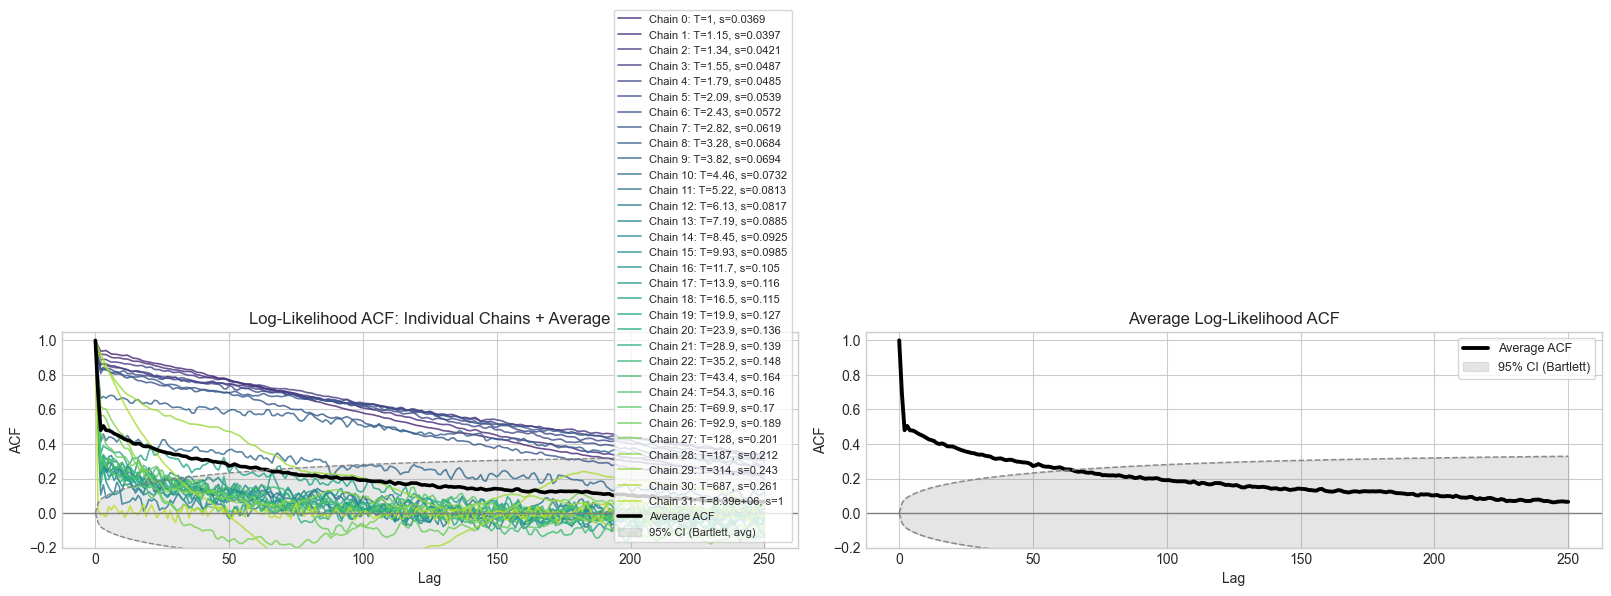

In [ ]:
from statsmodels.tsa.stattools import acf

# ----------------------------
# Autocorrelation diagnostics (log-likelihood)
# ----------------------------
alpha = 0.05
max_lag = min(250, max(20, n_steps // 4))
lags = np.arange(max_lag + 1)

acf_all = []
ci0_all = []  # zero-centered CI bounds like statsmodels plotting style

for i in range(N_chains):
    a_i, ci_i = acf(
        logL_hist[:, i],
        nlags=max_lag,
        fft=True,
        alpha=alpha,
        bartlett_confint=True,
    )
    acf_all.append(a_i)
    ci0_all.append(ci_i - a_i[:, None])  # convert to zero-centered bounds

acf_all = np.asarray(acf_all)          # (N_chains, max_lag+1)
ci0_all = np.asarray(ci0_all)          # (N_chains, max_lag+1, 2)

avg_acf = acf_all.mean(axis=0)
avg_low = ci0_all[:, :, 0].mean(axis=0)
avg_high = ci0_all[:, :, 1].mean(axis=0)

# ----------------------------
# Plot ACF: individual + average
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# Individual chains + average
ax = axes[0]
for i in range(N_chains):
    ax.plot(
        lags,
        acf_all[i],
        color=c_chains[i],
        lw=1.2,
        alpha=0.8,
        label=chain_labels[i],
    )
ax.plot(lags, avg_acf, color="black", lw=2.6, label="Average ACF")
ax.fill_between(
    lags,
    avg_low,
    avg_high,
    color="gray",
    alpha=0.18,
    label=f"{int((1-alpha)*100)}% CI (Bartlett, avg)",
)
ax.plot(lags, avg_high, color="gray", ls="--", lw=1.0, alpha=0.9)
ax.plot(lags, avg_low, color="gray", ls="--", lw=1.0, alpha=0.9)
ax.axhline(0.0, color="gray", lw=1.0)
ax.set_title("Log-Likelihood ACF: Individual Chains + Average")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_ylim(-0.2, 1.05)
ax.legend(fontsize=8, frameon=True, ncol=1)

# Average ACF only (clean view)
ax = axes[1]
ax.plot(lags, avg_acf, color="black", lw=2.8, label="Average ACF")
ax.fill_between(
    lags,
    avg_low,
    avg_high,
    color="gray",
    alpha=0.20,
    label=f"{int((1-alpha)*100)}% CI (Bartlett)",
)
ax.plot(lags, avg_high, color="gray", ls="--", lw=1.1, alpha=0.9)
ax.plot(lags, avg_low, color="gray", ls="--", lw=1.1, alpha=0.9)
ax.axhline(0.0, color="gray", lw=1.0)
ax.set_title("Average Log-Likelihood ACF")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_ylim(-0.2, 1.05)
ax.legend(fontsize=9, frameon=True)

plt.show()

In [ ]:
len(history)
history[1].shape

(1200, 31)

In [ ]:
history_log_L_current = []
history_accept = []

history_log_L_current = history[1]
history_accepted = history[2]

 ...]

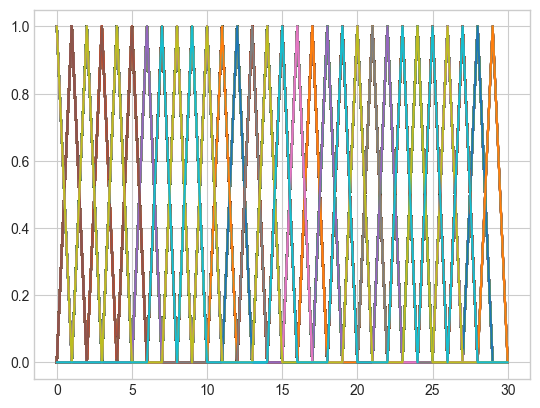

In [ ]:
plt.plot(history_log_L_current.T)

In [ ]:
proposal_dist_high = ProposalDistribution(dist=prior, step_size=0.2)
chain = ExtendedMetropolisChain(
    temperature=1.0,
    proposal_dist=proposal_dist_high,
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

state_current = prior(skey())
log_L_current = log_likelihood_gaussian(
    forward_model(state_current), data_obs, data_std
)

n_steps_tune = 50
key = skey()
target_acceptance_rate = 0.25
tune_interval = 25
learning_rate = 1.0
learning_rate_decay = 0.5


tuner = checkify.checkify(chain.tune)
err, (tuned_chain, history_tuned) = tuner(
    n_steps_tune=n_steps_tune,
    tune_interval=tune_interval,
    key=key,
    state_current=state_current,
    log_L_current=log_L_current,
    data_obs=data_obs,
    data_std=data_std,
    target_acceptance_rate=target_acceptance_rate,
    learning_rate=0.1,
    learning_rate_decay=0.5,
    progress=True,
)
err.throw()

TypeError: ExtendedMetropolisChain.__init__() got an unexpected keyword argument 'likelihood'

In [ ]:
temperatures = jnp.array([1.0, 2.0, 3.0])
step_sizes = jnp.array([0.1, 0.2, 0.3])

base_chain = ExtendedMetropolisChain(
    temperature=1.0,  # Placeholder, will be overridden by vmap
    proposal_dist=proposal_dist,  # Unbatched heavy object
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)


proposal_dists = ProposalDistribution(
    dist=prior,  # Unbatched heavy object
    step_size=step_sizes,  # Batched over step sizes
)

spec_proposal_dist = make_pytree_spec(
    proposal_dists,
    {
        "step_size": 0,  # Batch over step sizes
        "*": None,
    },
)

spec_chain = make_pytree_spec(
    base_chain,
    {
        "temperature": 0,  # Batch over temperatures
        "proposal_dist": spec_proposal_dist,  # Use the proposal_dist spec for the proposal_dist subtree
        "*": None,
    },
)
# @partial(jax.vmap, in_axes=(0, spec_proposal_dist), out_axes=spec_chain)
# def make_chains(temperature, proposal_dist):
#     return ExtendedMetropolisChain(
#         temperature=temperature,            # Batched: e.g. shape (3,)
#         proposal_dist=proposal_dist,         # Unbatched!
#         forward_model=forward_model,
#         likelihood=log_likelihood_gaussian,
#     )

# chains = make_chains(temperatures, proposal_dists)

chains = ExtendedMetropolisChain(
    temperature=temperatures,  # Batched: e.g. shape (3,)
    proposal_dist=proposal_dists,  # Unbatched!
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

pt = ParallelTemperingSampler(
    chains=chains,
)

states_current = prior(skey(), num_samples=len(temperatures))
log_Ls_current = jax.vmap(log_likelihood_gaussian, in_axes=(0, None, None))(
    forward_model(states_current), data_obs, data_std
)

out = pt(
    key=skey(),
    state_current=states_current,
    log_L_current=log_Ls_current,
    data_obs=data_obs,
    data_std=data_std,
)


In [ ]:
out = pt(
    key=skey(),
    state_current=states_current,
    log_L_current=log_Ls_current,
    data_obs=data_obs,
    data_std=data_std,
)
out

(Array([[[0.1299348 , 0.12804429, 0.12650528, ..., 0.12962825,
          0.12914523, 0.13019953],
         [0.12693137, 0.12628908, 0.12395938, ..., 0.12951652,
          0.13042343, 0.12995147],
         [0.12549766, 0.1247742 , 0.12436097, ..., 0.13177472,
          0.13178132, 0.13212013],
         ...,
         [0.1153875 , 0.11410155, 0.11347187, ..., 0.11236589,
          0.11398097, 0.1140482 ],
         [0.11735333, 0.11427144, 0.11384793, ..., 0.113335  ,
          0.11438687, 0.11544259],
         [0.11570746, 0.11447151, 0.11279379, ..., 0.11263193,
          0.1134246 , 0.11457952]],
 
        [[0.11660793, 0.11736497, 0.1165585 , ..., 0.11402393,
          0.11739128, 0.11994289],
         [0.11724625, 0.11712785, 0.11668506, ..., 0.11679341,
          0.11901086, 0.12010626],
         [0.11577575, 0.11566688, 0.11663912, ..., 0.11756585,
          0.1182269 , 0.12108527],
         ...,
         [0.11725384, 0.11466717, 0.1149524 , ..., 0.11848734,
          0.11617539, 0.

In [ ]:
multi_step_out = pt.step_n(100, skey(), states_current, log_Ls_current, data_obs, data_std, progress=True)

PT Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# Initialisation
N_temperatures = 5
initial_temperatures = jnp.geomspace(1.0, 4.0, N_temperatures)
initial_step_sizes = jnp.linspace(0.05, 0.2, N_temperatures)

observations = Observations(
    data_obs=data_obs,
    data_std=data_std,
)

# Set up chains with initial temperatures and step sizes
base_chain = ExtendedMetropolisChain(
    temperature=1.0,  # Placeholder, will be overridden by vmap
    proposal_dist=proposal_dist,  # Unbatched heavy object
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)


proposal_dists = ProposalDistribution(
    dist=prior,  # Unbatched heavy object
    step_size=step_sizes,  # Batched over step sizes
)

spec_proposal_dist = make_pytree_spec(
    proposal_dists,
    {
        "step_size": 0,  # Batch over step sizes
        "*": None,
    },
)

spec_chain = make_pytree_spec(
    base_chain,
    {
        "temperature": 0,  # Batch over temperatures
        "proposal_dist": spec_proposal_dist,  # Use the proposal_dist spec for the proposal_dist subtree
        "*": None,
    },
)

chains = ExtendedMetropolisChain(
    temperature=temperatures,  # Batched: e.g. shape (3,)
    proposal_dist=proposal_dists,  # Unbatched!
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

pt = ParallelTemperingSampler(
    chains=chains,
)

# Update initial states
initial_state = eqx.tree_at(lambda s: s.chains.temperature, pt, initial_temperatures)
initial_state = eqx.tree_at(lambda s: s.chains.proposal_dist.step_size, pt, initial_step_sizes)

# Update loss
log_Ls_initial = pt.chains.likelihood(
    pt.chains.forward_model(states_current), data_obs, data_std
)


In [ ]:
# Initially tune step size
tuner_pt = checkify.checkify(pt.tune)
err, (tuned_pt_step, (tuned_step_state, log_L_step_state), history_step) = tuner_pt(
    n_steps_tune=1000,
    tune_interval=100,
    key=skey(),
    state_current=initial_state,
    log_L_current=log_Ls_initial,
    data_obs=data_obs,
    data_std=data_std,
    learning_rate_step_size=0.1,
    learning_rate_step_size_decay=0.5,
    learning_rate_temperature=0.1,
    progress=True,
)
err.throw()

ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

In [ ]:
# Plot step size tuning history
fig, (ax_size, ax_rate) = plt.subplots(1, 2, figsize=(12, 5))
ax_size.plot(history_step[2])
ax_size.set_title("Step sizes history")
ax_rate.plot(history_step[3])
ax_rate.set_title("Step sizes acceptance rate")

fig, (ax_temp, ax_rate) = plt.subplots(1, 2, figsize=(12, 5))
ax_temp.plot(history_step[4])
ax_temp.set_title("Temperatures history")
ax_rate.plot(history_step[5])
ax_rate.set_title("Temperature swap acceptance rate")

In [ ]:

tuner_pt = checkify.checkify(pt.tune)
err, (tuned_pt, (state_final, log_L_final), history) = tuner_pt(
    n_steps_tune=2000,
    tune_interval=200,
    key=skey(),
    state_current=states_current,
    log_L_current=log_Ls_current,
    data_obs=data_obs,
    data_std=data_std,
    initial_step_sizes=jnp.linspace(0.03, 0.08, len(temperatures)),
    initial_temperatures=jnp.geomspace(1.0, 2.5, len(temperatures)),
    learning_rate_temperature=0.1,
    learning_rate_temperature_decay=0.7,
    progress=True,
)
err.throw()

In [ ]:
display(tuned_pt.chains.proposal_dist.step_size)
display(tuned_pt.chains.temperature)

In [ ]:
# Temperatures and step sizes history
fig, (ax_size, ax_rate) = plt.subplots(1, 2, figsize=(12, 5))
ax_size.plot(history[2])
ax_size.set_title("Step sizes history")
ax_rate.plot(history[3])
ax_rate.set_title("Step sizes acceptance rate")

fig, (ax_temp, ax_rate) = plt.subplots(1, 2, figsize=(12, 5))
ax_temp.plot(history[4])
ax_temp.set_title("Temperatures history")
ax_rate.plot(history[5])
ax_rate.set_title("Temperature swap acceptance rate")


In [ ]:
plt.plot(history[2])
plt.figure()
plt.plot(history[3])


In [ ]:
out

In [ ]:
# # Assuming ExtendedMetropolisChain and make_pytree_spec are available
# class ParallelTemperingSampler(eqx.Module):
#     chains: ExtendedMetropolisChain
#     spec: jax.tree_util.PyTreeDef
#     n_chains: int = eqx.field(static=True)

#     def __init__(
#         self,
#         temperatures: jax.Array,
#         proposal_dist,
#         forward_model: Callable,
#         likelihood: Callable,
#     ):
#         self.n_chains = len(temperatures)

#         self.chains = ExtendedMetropolisChain(
#             temperature=temperatures,
#             proposal_dist=proposal_dist,
#             forward_model=forward_model,
#             likelihood=likelihood,
#         )

#         self.spec = make_pytree_spec(
#             self.chains,
#             {
#                 "temperature": 0,
#                 "*": None,
#             },
#         )

#     def _swap_adjacent(self, key, states, log_Ls, offset):
#         """
#         Attempts to swap states and log-likelihoods between adjacent chains.
#         offset=0 permits swaps on (0,1), (2,3). offset=1 permits (1,2), (3,4).
#         By masking rather than dynamically slicing, we keep array sizes static.
#         """
#         idx1 = jnp.arange(self.n_chains - 1)
#         idx2 = idx1 + 1

#         log_L1 = log_Ls[idx1]
#         log_L2 = log_Ls[idx2]
#         T1 = self.chains.temperature[idx1]
#         T2 = self.chains.temperature[idx2]

#         # PT swap acceptance log-probability
#         delta_log_L = log_L2 - log_L1
#         delta_inv_T = (1.0 / T1) - (1.0 / T2)
#         log_alpha = delta_log_L * delta_inv_T

#         u = jax.random.uniform(key, shape=log_alpha.shape)

#         # Accept if:
#         # 1) standard metropolis criteria is met
#         # 2) the index matches the current alternating offset (even or odd pair)
#         accept = (jnp.log(u) < log_alpha) & ((idx1 % 2) == offset)

#         def swap_if(x, accept_mask):
#             # Scan iteratively to apply swaps sequentially.
#             # Doing this ensures that if chained swaps were permitted, we don't clobber things,
#             # but since we mask by parity (offset), no chain is swapped twice in one step.
#             def step_fn(carry, i):
#                 arr = carry
#                 val1, val2 = arr[i], arr[i + 1]
#                 # If accept_mask[i] is True, swap the contents
#                 new_val1 = jnp.where(accept_mask[i], val2, val1)
#                 new_val2 = jnp.where(accept_mask[i], val1, val2)
#                 arr = arr.at[i].set(new_val1).at[i + 1].set(new_val2)
#                 return arr, None

#             final_arr, _ = jax.lax.scan(step_fn, x, jnp.arange(self.n_chains - 1))
#             return final_arr

#         new_states = swap_if(states, accept)
#         new_log_Ls = swap_if(log_Ls, accept)

#         return new_states, new_log_Ls, jnp.sum(accept)

#     @eqx.filter_jit
#     def step(self, key, current_state, log_L_current, swap_offset):
#         # 1. Standard MCMC step for all chains
#         step_key, swap_key = jax.random.split(key)

#         @partial(jax.vmap, in_axes=(0, self.spec, 0, 0))
#         def _step_local(k, chain_b, state_b, log_L_b):
#             # Assumes chain.__call__ returns standard MCMC inputs
#             # Check cell 21 in your notebook for exact outputs; usually: state, log_L, accepted
#             return chain_b(k, state_b, log_L_b, data_obs, data_std)

#         keys = jax.random.split(step_key, self.n_chains)

#         # Note: adjust this unpacking if your step function returns an accept array
#         new_state, new_log_L, _ = _step_local(
#             keys, self.chains, current_state, log_L_current
#         )

#         # 2. Replica exchange swap
#         return self._swap_adjacent(swap_key, new_state, new_log_L, swap_offset)

#     @eqx.filter_jit
#     def step_n(self, n_steps, key, start_state, start_log_L):
#         def _scan_fn(carry, step_key):
#             state, log_L, i = carry

#             # Alternate between even/odd swaps (i % 2) for detailed balance
#             # E.g., step 0 -> offset 0, step 1 -> offset 1
#             offset = i % 2

#             next_state, next_log_L, num_swaps = self.step(
#                 step_key, state, log_L, offset
#             )
#             out = (next_state, next_log_L, num_swaps)

#             return (next_state, next_log_L, i + 1), out

#         keys = jax.random.split(key, n_steps)
#         final_carry, history = jax.lax.scan(
#             _scan_fn, (start_state, start_log_L, jnp.array(0, dtype=jnp.int32)), keys
#         )

#         # history contains (states_history, log_L_history, swap_count_history)
#         return (final_carry[0], final_carry[1]), history


# # --- Test the sampler ---
# proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)

# N_chains = 4
# temperatures = jnp.geomspace(1.0, 5.0, N_chains)
# pt_sampler = ParallelTemperingSampler(
#     temperatures=temperatures,
#     proposal_dist=proposal_dist,
#     forward_model=forward_model,
#     likelihood=log_likelihood_gaussian,
# )

# # Setup initial distributions
# state_current = prior(skey(), num_samples=N_chains)


# # Use JIT and correctly vectorize log-L evaluation
# @jax.jit
# def get_initial_log_L(st):
#     return jax.vmap(log_likelihood_gaussian, in_axes=(0, None, None))(
#         forward_model(st), data_obs, data_std,
#     )


# log_L_current = get_initial_log_L(state_current)

# N_steps = 100
# (final_state, final_log_L), history = pt_sampler.step_n(
#     N_steps, skey(), state_current, log_L_current
# )
# states_hist, log_l_hist, swap_counts = history

In [ ]:
import matplotlib.pyplot as plt

# Compute cumulative acceptances and ratio across the chain dimension
# accepts has shape: (N_chains, N_steps)
cumulative_accepts = np.cumsum(accepts, axis=1)

# To calculate ratio, we need step numbers: 1 to N_steps
step_indices = np.arange(1, N_steps + 1)
acceptance_ratios = cumulative_accepts / step_indices[None, :]

# Set up the plot grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Use a colormap distinct for each chain
colors = plt.cm.tab10(np.linspace(0, 1, N_chains))

# Plot 1: Cumulative Acceptances
for i in range(N_chains):
    axes[0].plot(
        step_indices,
        cumulative_accepts[i],
        label=f"Chain {i} (T={temperatures_j[i]:.1f})",
        color=colors[i],
    )
axes[0].set_title("Cumulative Accepted Proposals")
axes[0].set_xlabel("MCMC Step")
axes[0].set_ylabel("Total Acceptances")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Acceptance Ratio over Time
for i in range(N_chains):
    axes[1].plot(
        step_indices,
        acceptance_ratios[i],
        label=f"Chain {i} (T={temperatures_j[i]:.1f})",
        color=colors[i],
    )
axes[1].set_title("Acceptance Ratio")
axes[1].set_xlabel("MCMC Step")
axes[1].set_ylabel("Acceptance Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np

# --- Configuration ---
N_chains = 8
N_steps_per_phase = 50

N_steps_burnin = 100  # Steps to throw away
N_steps_sampling = 1000  # Steps to keep

assert N_steps_burnin % N_steps_per_phase == 0, (
    "Burn-in steps must be a multiple of steps per phase"
)
assert N_steps_sampling % N_steps_per_phase == 0, (
    "Sampling steps must be a multiple of steps per phase"
)
N_phases_burnin = N_steps_burnin // N_steps_per_phase
N_phases_sampling = N_steps_sampling // N_steps_per_phase

temperatures_j = jnp.geomspace(1.0, 20.0, num=N_chains)

# Setup initial constraints
master_key = jax.random.PRNGKey(1234)
setup_key, runtime_key = jax.random.split(master_key)

initial_states = prior(setup_key, num_samples=N_chains)
initial_travel_times = forward_model(initial_states)
vmap_log_L = jax.vmap(log_likelihood_gaussian, in_axes=(0, None, None))
initial_log_Ls = vmap_log_L(data_obs, data_std, initial_travel_times)


# -------------------------------------------------------------------------
# THE COMPILED PARALLEL TEMPERING ORCHESTRATOR
# -------------------------------------------------------------------------
@jax.jit(static_argnames=["forward_model", "N_steps_per_phase", "N_phases"])
def pt_scan_loop(
    rng_key,
    initial_states,
    initial_log_Ls,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures,
    N_steps_per_phase,
    N_phases,
    phase_idx_offset,
):
    keys = jax.random.split(rng_key, N_phases)
    phase_indices = jnp.arange(N_phases) + phase_idx_offset

    # We natively generate base indexes here to keep array lengths statically safe
    left_base_indices = np.arange(0, len(temperatures), 2)

    @scan_tqdm(N_phases, print_rate=1, tqdm_type="auto")
    def pt_phase_body(carry, scan_input):
        i_phase, phase_key, phase_idx = scan_input
        current_states, current_log_Ls = carry

        swap_key, chain_run_key = jax.random.split(phase_key)
        chain_keys = jax.random.split(chain_run_key, len(temperatures))

        # 1. Run local MCMC block (Uses your custom mapped vmap_run_mcmc from earlier)
        (post_mcmc_states, post_mcmc_log_Ls), history = vmap_run_mcmc(
            chain_keys,
            current_states,
            current_log_Ls,
            proposal_dist,
            data_obs,
            data_std,
            forward_model,
            temperatures,
            N_steps_per_phase,
        )

        # 2. Vectorized PT SWAP LOGIC
        # Deterministically flips between Phase Check Pairings [0-1, 2-3] vs [1-2, 3-3(ignored)]
        start_idx = phase_idx % 2

        # Construct pair indices, clipping to prevent Array OOB exceptions natively
        left_idx = jnp.clip(left_base_indices + start_idx, 0, len(temperatures) - 1)
        right_idx = jnp.clip(left_idx + 1, 0, len(temperatures) - 1)

        beta = 1.0 / temperatures
        log_L_left = post_mcmc_log_Ls[left_idx]
        log_L_right = post_mcmc_log_Ls[right_idx]
        beta_left = beta[left_idx]
        beta_right = beta[right_idx]

        log_swap_ratio = (log_L_left - log_L_right) * (beta_right - beta_left)
        log_u = jnp.log(
            jax.random.uniform(swap_key, shape=(left_base_indices.shape[0],))
        )

        do_swap = log_u < log_swap_ratio

        states_left = post_mcmc_states[left_idx]
        states_right = post_mcmc_states[right_idx]

        # Broadcast where condition along grids using specialized axes mapping
        vmap_where = jax.vmap(jnp.where, in_axes=(0, 0, 0))
        new_states_left = vmap_where(do_swap, states_right, states_left)
        new_states_right = vmap_where(do_swap, states_left, states_right)

        new_log_L_left = jnp.where(do_swap, log_L_right, log_L_left)
        new_log_L_right = jnp.where(do_swap, log_L_left, log_L_right)

        # Reconstruct the full 4D stacked tensors
        new_states = post_mcmc_states.at[left_idx].set(new_states_left)
        new_states = new_states.at[right_idx].set(new_states_right)

        new_log_Ls = post_mcmc_log_Ls.at[left_idx].set(new_log_L_left)
        new_log_Ls = new_log_Ls.at[right_idx].set(new_log_L_right)

        # Calculate successful swaps (ignoring duplicate "clones" we make to bypass OOB problems)
        num_swaps = jnp.sum(jnp.where(left_idx != right_idx, do_swap, False))

        samples_j, log_L_j, accepts_j = history
        history_out = (samples_j, log_L_j, accepts_j, num_swaps)

        return (new_states, new_log_Ls), history_out

    return jax.lax.scan(
        pt_phase_body,
        (initial_states, initial_log_Ls),
        (jnp.arange(N_phases), keys, phase_indices),
    )


# -------------------------------------------------------------------------
# EXECUTION
# -------------------------------------------------------------------------
print(f"Starting Fully Compiled Parallel Tempering...")
print(f"Phase chunk target: {N_steps_per_phase} consecutive steps")
print(f"Burn-in: {N_steps_burnin} total steps")
print(f"Sampling: {N_steps_sampling} total steps\n")

burnin_run_key, sampling_run_key = jax.random.split(runtime_key)

# 1. BURN-IN
print("Compiling and executing Burn-in...")
burnin_carry, burnin_hist = pt_scan_loop(
    burnin_run_key,
    initial_states,
    initial_log_Ls,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures_j,
    N_steps_per_phase,
    N_phases=N_phases_burnin,
    phase_idx_offset=0,
)
_, _, _, burnin_swaps = burnin_hist  # Throwing away matrices
print(f"Burn-in successful block swaps: {burnin_swaps.tolist()}")

# 2. SAMPLING (Compiles automatically into dynamic graph the first time N_phases_sampling invokes)
print("Compiling and executing Sampling...")
sampling_carry, sampling_hist = pt_scan_loop(
    sampling_run_key,
    burnin_carry[0],
    burnin_carry[1],
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures_j,
    N_steps_per_phase,
    N_phases=N_phases_sampling,
    phase_idx_offset=N_phases_burnin,
)
samples_j, log_L_j, accepts_j, sampling_swaps = sampling_hist
print(f"Sampling successful block swaps: {sampling_swaps.tolist()}")

# -------------------------------------------------------------------------
# FORMAT ARRAY HISTORIES BACK NATIVE
# -------------------------------------------------------------------------
# History shape is natively returned mapped as: (N_phases, N_chains, N_steps_per_phase, nx, ny)
# We flatten phases and blocks into the chronological continuous timeline: (N_chains, Total_Steps, nx, ny)

final_samples = jnp.swapaxes(samples_j, 0, 1).reshape(
    N_chains, -1, *samples_j.shape[3:]
)
final_log_Ls = jnp.swapaxes(log_L_j, 0, 1).reshape(N_chains, -1)
final_accepts = jnp.swapaxes(accepts_j, 0, 1).reshape(N_chains, -1)

# Pass off to CPU memory as standard numpy
final_samples = np.array(final_samples)
final_log_Ls = np.array(final_log_Ls)
final_accepts = np.array(final_accepts)

print(f"\nFinal pipeline completed!")
print(f"Total saved samples array: {final_samples.shape}")
print(
    f"Total acceptances handled per chain (post-burnin): {np.sum(final_accepts, axis=1)}"
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Total steps across all phases
total_steps = final_accepts.shape[1]
step_indices = np.arange(1, total_steps + 1)

# Compute cumulative acceptances and global ratio across the chain dimension
cumulative_accepts = np.cumsum(final_accepts, axis=1)
acceptance_ratios = cumulative_accepts / step_indices[None, :]

# Compute Windowed (Rolling) Acceptance Rate
window_size = min(50, total_steps)  # 50 steps, or max steps if fewer
window_steps = np.arange(window_size, total_steps + 1)

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Use a colormap distinct for each chain
colors = plt.cm.tab10(np.linspace(0, 1, N_chains))

# Plot 1: Log-Likelihood Trace
for i in range(N_chains):
    axes[0].plot(
        step_indices,
        final_log_Ls[i],
        alpha=0.7,
        label=f"Chain {i} (T={temperatures_j[i]:.1f})",
        color=colors[i],
    )
axes[0].set_title("Log-Likelihood Trace")
axes[0].set_xlabel("Total MCMC Steps")
axes[0].set_ylabel("Log L")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cumulative Acceptances
for i in range(N_chains):
    axes[1].plot(
        step_indices, cumulative_accepts[i], label=f"Chain {i}", color=colors[i]
    )
axes[1].set_title("Cumulative Accepted Proposals")
axes[1].set_xlabel("Total MCMC Steps")
axes[1].set_ylabel("Total Acceptances")
axes[1].grid(True, alpha=0.3)

# Plot 3: Global Acceptance Ratio (Cumulative)
for i in range(N_chains):
    axes[2].plot(
        step_indices, acceptance_ratios[i], label=f"Chain {i}", color=colors[i]
    )
axes[2].set_title("Global Acceptance Ratio")
axes[2].set_xlabel("Total MCMC Steps")
axes[2].set_ylabel("Acceptance Rate")
axes[2].grid(True, alpha=0.3)

# Plot 4: Windowed Acceptance Ratio
for i in range(N_chains):
    # Rolling mean using 1D convolution
    windowed_acc = np.convolve(
        final_accepts[i], np.ones(window_size) / window_size, mode="valid"
    )
    axes[3].plot(
        window_steps, windowed_acc, alpha=0.8, label=f"Chain {i}", color=colors[i]
    )
axes[3].set_title(f"Rolling Acceptance Rate (Window={window_size})")
axes[3].set_xlabel("Total MCMC Steps")
axes[3].set_ylabel("Local Acceptance Rate")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
samples.shape
samples_mean = np.mean(samples, axis=(0, 1))
samples_var = np.var(samples, axis=(0, 1))

plt.figure(figsize=(6, 8))
plt.subplot(1, 2, 1)
plt.imshow(
    samples_mean.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Mean Velocity Variation")
plt.subplot(1, 2, 2)
plt.imshow(
    samples_var.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Variance of Velocity Variation")
plt.tight_layout()

In [ ]:
raise NotImplementedError(
    "This is just a demo of how to set up the parallel chains. You can now experiment with different temperatures, proposal distributions, or even implement swap steps between chains for parallel tempering!"
)

In [ ]:
# Try extended metropolis

seeder = gs.random.MasterRNG(20170519)

N_steps = 3
m_current = srf.structured((x, y), seed=seeder())
log_L_current = log_likelihood_gaussian(data_obs, data_std, forward_model(m_current))
for i in range(N_steps):
    m_proposal = srf.structured((x, y), seed=seeder())
    log_L_proposal = log_likelihood_gaussian(
        data_obs, data_std, forward_model(m_proposal)
    )

    log_acceptance_ratio = log_L_proposal - log_L_current
    if np.log(np.random.rand()) < log_acceptance_ratio:
        m_current = m_proposal
        log_L_current = log_L_proposal

In [ ]:
from nanopinv.sampler import ExtendedMetropolisSampler, SRFProposalDistribution

rng = np.random.default_rng(20170519)
rng_accept = rng.spawn(1)[0]

temperature = 1.0

In [ ]:
proposal_dist = SRFProposalDistribution(
    srf=srf, r=[x, y], step_size=0.06, rng=rng.spawn(1)[0]
)

state_current = proposal_dist.propose(state_current=None)
travel_times_current = forward_model(state_current)
log_L_current = log_likelihood_gaussian(data_obs, data_std, travel_times_current)

In [ ]:
samples = []
data = []
N_steps = 2500
N_done = 0
N_accepted = 0
for i in trange(N_steps):
    state_proposal = proposal_dist.propose(state_current=state_current)
    print(state_proposal.shape)
    if not np.all(state_proposal > 0):
        print("Proposal has negative values, rejecting.")
        continue
    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    # print(f"log_ratio: {log_ratio}")
    log_P_accept = min(0.0, log_ratio)
    P_accept = np.exp(log_P_accept)
    # print(f"log_P_accept: {log_P_accept}")
    # print(f"P_accept: {P_accept}")

    if rng_accept.random() < P_accept:
        state_current = state_proposal
        log_L_current = log_L_proposal
        N_accepted += 1

    samples.append(state_current.copy())
    N_done += 1

    data.append(
        {
            "step": N_done,
            "log_P_accept": log_P_accept,
            "P_accept": P_accept,
            "accepted": N_accepted,
            "acceptance_rate": N_accepted / N_done,
        }
    )

In [ ]:
from nanopinv.sampler_jax import ProposalDistribution

samples = []
data = []
N_steps = 2500
N_done = 0
N_accepted = 0

temperature = 1.0

rng_key = jax.random.PRNGKey(0)

rng_key, initial_key = jax.random.split(rng_key)

proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)
state_current = prior(initial_key)
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)


@jax.jit(static_argnames=["forward_model"])
def do_step(
    key,
    state_current,
    log_L_current,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
):
    proposal_key, accept_key = jax.random.split(key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept[None, None], state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    return state_next, log_L_next, accept


# LOOP_STEPSIZE = 10
# for i in trange(N_steps):
#     new_keys = jax.random.split(rng_key, num=LOOP_STEPSIZE + 1)
#     rng_key = new_keys[0]
#     iteration_keys = new_keys[1:]

#     state_current, log_L_current, accept = do_N_step(
#         iteration_keys,
#         state_current,
#         log_L_current,
#         proposal_dist,
#         data_obs,
#         data_std,
#         forward_model,
#         temperature,
#     )

#     N_accepted += jnp.sum(accept)
#     N_done += 1

#     samples.append(state_current.copy())

#     data.append(
#         {
#             "step": N_done,
#             "accepted": N_accepted,
#             "acceptance_rate": N_accepted / N_done,
#         }
#     )

for i in trange(N_steps):
    rng_key, iteration_key = jax.random.split(rng_key)
    state_current, log_L_current, accept = do_step(
        rng_key,
        state_current,
        log_L_current,
        proposal_dist,
        data_obs,
        data_std,
        forward_model,
        temperature,
    )

    N_accepted += jnp.sum(accept)
    N_done += 1

    samples.append(state_current.copy())

    data.append(
        {
            "step": N_done,
            "accepted": N_accepted,
            "acceptance_rate": N_accepted / N_done,
        }
    )


# for i in trange(N_steps):
#     rng_key, proposal_key, accept_key = jax.random.split(rng_key, num=3)
#     state_proposal = proposal_dist.propose(key=proposal_key, state_current=state_current)
#     if not np.all(state_proposal > 0):
#         print("Proposal has negative values, rejecting.")
#         continue
#     travel_times_proposal = forward_model(state_proposal)
#     log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

#     log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
#     # print(f"log_ratio: {log_ratio}")
#     log_P_accept = min(0.0, log_ratio)
#     P_accept = np.exp(log_P_accept)
#     # print(f"log_P_accept: {log_P_accept}")
#     # print(f"P_accept: {P_accept}")

#     if jax.random.uniform(accept_key) < P_accept:
#         state_current = state_proposal
#         log_L_current = log_L_proposal
#         N_accepted += 1

#     samples.append(state_current.copy())
#     N_done += 1

#     data.append({
#         "step": N_done,
#         "log_P_accept": log_P_accept,
#         "P_accept": P_accept,
#         "accepted": N_accepted,
#         "acceptance_rate": N_accepted / N_done,
#     })

In [ ]:
%load_ext line_profiler


def mcmc_loop_profile(
    proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=50
):
    """Profile target for line_profiler."""
    samples = []
    data = []
    N_done = 0
    N_accepted = 0

    for i in range(N_steps):
        state_proposal = proposal_dist.propose(state_current=state_current)
        travel_times_proposal = forward_model(state_proposal)
        log_L_proposal = log_likelihood_gaussian(
            data_obs, data_std, travel_times_proposal
        )

        log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
        log_P_accept = min(0.0, log_ratio)
        P_accept = np.exp(log_P_accept)

        if rng_accept.random() < P_accept:
            state_current = state_proposal
            log_L_current = log_L_proposal
            N_accepted += 1

        samples.append(state_current.copy())
        N_done += 1

        data.append(
            {
                "step": N_done,
                "log_likelihood": log_L_current,
                "accepted": N_accepted,
                "acceptance_rate": N_accepted / N_done,
            }
        )

    return samples, data, N_accepted, N_done


# # Profile the loop and proposal method
# print("=== LINE PROFILER: MCMC Loop ===")
# %lprun -f forward_model -f mcmc_loop_profile mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=50)

# print("\n=== LINE PROFILER: Propose Method ===")
# %lprun -f proposal_dist.propose mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=10)

# print("\n=== Diagnostics ===")
# print(f"Grid shape: {state_current.shape}")
# print(f"Grid size (elements): {state_current.size}")
# print(f"Proposal step_size: {proposal_dist.step_size}")
# print(f"# Unique sources: {len(np.unique(sources, axis=0))}")

In [ ]:
samples_arr = np.array(samples)

In [ ]:
mean_samples = np.mean(samples_arr, axis=0)
var_samples = np.var(samples_arr, axis=0)

plt.figure()
plt.imshow(
    mean_samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Mean Slowness")

plt.figure()
plt.imshow(
    var_samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Variance of Slowness")

In [ ]:
import polars as pl

df = pl.DataFrame(data)
df

sns.lineplot(data=df, x="step", y="accepted")
plt.figure()
sns.lineplot(data=df, x="step", y="acceptance_rate")

In [ ]:
import jax.lax as lax


# First, define your single step exactly as you did, slightly modified to
# package the inputs and outputs structurally for lax.scan
@jax.jit(static_argnames=["forward_model"])
def mcmc_scan_body(
    carry,  # The current state that carries over chain steps
    step_key,  # The specific pre-split rng key for this one iteration
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
):
    # Unpack the carry
    state_current, log_L_current = carry

    proposal_key, accept_key = jax.random.split(step_key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept, state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    # Package the updated state for the next step
    new_carry = (state_next, log_L_next)

    # Let's save the current state and whether we accepted as the history arrays
    history_output = (state_next, log_L_next, accept)

    return new_carry, history_output


# Now, build wrapper that JIT compiles the full loop execution
@jax.jit(static_argnames=["forward_model", "N_steps"])
def run_mcmc_chain(
    rng_key,
    initial_state,
    initial_log_L,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
):
    # Pre-generate ALL random keys for the entire chain simultaneously avoiding sequential splits
    keys = jax.random.split(rng_key, N_steps)

    # We must explicitly freeze static objects into the scan closure
    def scan_fn(carry, step_key):
        return mcmc_scan_body(
            carry,
            step_key,
            proposal_dist,
            data_obs,
            data_std,
            forward_model,
            temperature,
        )

    initial_carry = (initial_state, initial_log_L)

    # jax.lax.scan sequentially applies `scan_fn`.
    # It passes initial_carry and keys[0], gets new_carry_1 and out_1.
    # It passes new_carry_1 and keys[1], gets new_carry_2 and out_2...
    final_carry, history = lax.scan(scan_fn, initial_carry, keys)

    return final_carry, history


# --- RUNNING THE CHAIN ---
N_steps = 2500

state_current = prior(initial_key)
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)

final_carry, (samples_j, log_L_j, accepts_j) = run_mcmc_chain(
    rng_key,
    state_current,
    log_L_current,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
)

# Convert mapped history into numpy
samples = np.array(samples_j)
log_L_history = np.array(log_L_j)
accepts = np.array(accepts_j)

# You can reconstruct your stats DataFrame easily because
# standard numpy vector operations are faster than loop appends anyway
steps = np.arange(1, N_steps + 1)
cumulative_accepts = np.cumsum(accepts)

data = []
for i in range(N_steps):
    data.append(
        {
            "step": steps[i],
            "accepted": cumulative_accepts[i],
            "acceptance_rate": cumulative_accepts[i] / steps[i],
        }
    )

In [ ]:
samples.shape
samples_mean = np.mean(samples, axis=(0))
samples_var = np.var(samples, axis=(0))

plt.figure(figsize=(6, 8))
plt.subplot(1, 2, 1)
plt.imshow(
    samples_mean.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Mean Velocity Variation")
plt.subplot(1, 2, 2)
plt.imshow(
    samples_var.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Variance of Velocity Variation")
plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def compute_autocorr(x):
    """Computes the 1D normalized autocorrelation function."""
    x = x - np.mean(x)
    # Compute full cross-correlation
    corr = np.correlate(x, x, mode="full")
    # Keep only the second half (lags >= 0)
    corr = corr[corr.size // 2 :]
    # Normalize by the 0-lag (which is the variance)
    return corr / corr[0]


# 1. ACF of the Log-Likelihood
acf_log_L = compute_autocorr(log_L_history)

# 2. ACF of a specific pixel in the middle of the grid
mid_x, mid_y = samples.shape[1] // 2, samples.shape[2] // 2
pixel_trace = samples[:, mid_x, mid_y]
acf_pixel = compute_autocorr(pixel_trace)

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(acf_log_L, label="Log-Likelihood", alpha=0.9)
plt.plot(acf_pixel, label=f"Middle Pixel ({mid_x}, {mid_y})", alpha=0.9)

# Formatting
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
# Add bounds to indicate when correlation becomes negligible
plt.axhline(0.1, color="red", linestyle=":", alpha=0.5, label="±0.1 threshold")
plt.axhline(-0.1, color="red", linestyle=":", alpha=0.5)

plt.xlabel("Lag (Steps)")
plt.ylabel("Autocorrelation")
plt.title("MCMC Autocorrelation Function (ACF)")
plt.legend()

# Zoom in on the early steps where the drop-off happens
# You can adjust this xlim depending on how slow the mixing is
plt.xlim(0, min(500, len(log_L_history)))
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
forward = forward_model(samples[-1, :, :])

forwards = forward_model(samples[::10])

In [ ]:
forwards_mean = np.mean(forwards, axis=0)
forwards_var = np.var(forwards, axis=0)
forwards_ci = 1.96 * np.sqrt(forwards_var)
forwards_ub = forwards_mean + forwards_ci
forwards_lb = forwards_mean - forwards_ci

In [ ]:
plt.plot(forwards_mean, label="Mean Forward Prediction")
plt.fill_between(
    np.arange(len(forwards_mean)),
    forwards_lb,
    forwards_ub,
    alpha=0.3,
    label="95% Credible Interval",
)
plt.plot(data_obs, alpha=0.7)

In [ ]:
import numpy as np

# 1. Thin your true posterior to evaluate network efficiency
thinned_samples = posterior_samples[500::10]  # Discard some burn-in if needed & thin
forwards = forward_model(thinned_samples)
forwards_mean = np.mean(forwards, axis=0)

# 2. Add random observational noise to the simulated travel times mathematically
noisy_forwards = forwards + np.random.normal(0, data_std, size=forwards.shape)

# 3. Pull Empirical 95% Interval
predictive_lb = np.percentile(noisy_forwards, 2.5, axis=0)
predictive_ub = np.percentile(noisy_forwards, 97.5, axis=0)

# --- Plotting ---
plt.figure(figsize=(12, 6))

plt.fill_between(
    np.arange(len(forwards_mean)),
    predictive_lb,
    predictive_ub,
    color="gray",
    alpha=0.3,
    label="95% Predictive Interval (Includes Noise)",
)

plt.plot(forwards_mean, color="blue", label="Mean Prediction")
plt.plot(
    data_obs,
    color="red",
    marker=".",
    linestyle="none",
    alpha=0.7,
    label="Observed Data",
)
plt.xlabel("Data Index")
plt.ylabel("Travel Time")
plt.legend()
plt.show()

TODO: 

Read [](file:///c%3A/Users/jeppe/Documents/MEGA/Base/DTU/30760%20Inverse%20Problems%20and%20Machine%20Learning%20in%20Earth%20and%20Space%20Physics/nanopinv/nanopinv)

Read [](file:///c%3A/Users/jeppe/Documents/MEGA/Base/DTU/30760%20Inverse%20Problems%20and%20Machine%20Learning%20in%20Earth%20and%20Space%20Physics/nanopinv/nanopinv/sampler_jax.py)

I have reviewed the entire notebook and the associated mathematical implementation. While your Parallel Tempering and JAX compilations are extremely solid, there are **three critical bugs** involving how you transition from PT MCMC sampling to downstream inference/plotting. 

These will lead to severely incorrect scientific outputs (and broken arrays) if not corrected.

### 1. Mixing High-Temperature Chains into the Posterior (Critical Scientific Bug)
In Parallel Tempering, **only the base chain ($T=1.0$) represents the true posterior distribution.** The higher-temperature chains are mathematically flattened to explore wide spaces and are invalid for inference plotting.

By using `samples = np.array(samples_j)` or the full `final_samples` array from `pt_scan_loop`, you end up with a 4D array: `(N_chains, Total_Steps, nx, ny)`. 
If you simply evaluate `np.mean(final_samples, axis=(0, 1))`, you are averaging the "hot" physics in with the real physics, completely destroying your spatial certainty.

**The Fix:** You must exclusively extract `Chain 0` (since `temperatures_j[0] = 1.0`) before calculating stats or forwards:
```python
# Extract the T=1.0 cold chain ONLY
posterior_samples = final_samples[0]  # Shape: (Total_Steps, nx, ny)

samples_mean = np.mean(posterior_samples, axis=0) # Now shape (nx, ny)
samples_var = np.var(posterior_samples, axis=0)
```

### 2. Slicing the Wrong Axis for `forwards` (Code Crashing Bug)
If you evaluate `forwards = forward_model(final_samples[::10])`, you will mistakenly slice the `N_chains` axis, yielding a chunk of 4D arrays. If your `build_time_travel_points` is strictly waiting for 3D `(batch, nx, ny)`, it will throw an unreadable nested XLA shape exception.

**The Fix:** Slice the dimension of the isolated `posterior_samples`:
```python
# Safely thins the time steps from the T=1.0 chain
forwards = forward_model(posterior_samples[::10]) 
```

### 3. Adding Standard Deviations Linearly (Mathematical Metric Bug)
In the prediction bounds you shared:
`predictive_lb = forwards_lb_model - (1.96 * data_std)`
Standard deviations do not algebraically add linearly—*variances* do ($\sigma_{total} = \sqrt{\sigma_{model}^2 + \sigma_{noise}^2}$). Adding $1.96 \cdot \sigma$ linearly significantly **overestimates** your uncertainty bounds. 

Furthermore, if the model bounds are not perfectly Gaussian, you distort the distribution. In MCMC, the gold standard for "Posterior Predictive Uncertainty" is physically simulating the noise directly onto the prediction tensor before finding percentiles.

**The Fix:**
```python
import numpy as np

# 1. Thin your true posterior to evaluate network efficiency 
thinned_samples = posterior_samples[500::10] # Discard some burn-in if needed & thin
forwards = forward_model(thinned_samples)
forwards_mean = np.mean(forwards, axis=0)

# 2. Add random observational noise to the simulated travel times mathematically
noisy_forwards = forwards + np.random.normal(0, data_std, size=forwards.shape)

# 3. Pull Empirical 95% Interval
predictive_lb = np.percentile(noisy_forwards, 2.5, axis=0)
predictive_ub = np.percentile(noisy_forwards, 97.5, axis=0)

# --- Plotting ---
plt.figure(figsize=(12, 6))

plt.fill_between(
    np.arange(len(forwards_mean)),
    predictive_lb,
    predictive_ub,
    color='gray',
    alpha=0.3,
    label="95% Predictive Interval (Includes Noise)"
)

plt.plot(forwards_mean, color='blue', label="Mean Prediction")
plt.plot(data_obs, color='red', marker='.', linestyle='none', alpha=0.7, label="Observed Data")
plt.xlabel("Data Index"); plt.ylabel("Travel Time"); plt.legend()
plt.show()
```

### 4. (Sanity Check) JAX Negative Velocities
*Context:* Your Proposal uses a Preconditioned Crank-Nicolson (pCN) update assuming values distribute around `mean = 0.12`. 
Eventually, the tails of these Gaussian mutations will propose negative slownesses/velocities. Since you `jax.jit` the `do_step` execution, if your eikonal solver doesn't safely clip negative values at the compiler level, the matrix will silently spit `NaNs`. Once the likelihood calculates `NaN`, the Parallel Tempering locks onto the NaN indefinitely. 

Just ensure somewhere either inside `propose()` or your Eikonal wrapper you strictly bind the lower floor via `jnp.maximum(tensor, 1e-6)`.